# Continuation models — ensemble comparison

Compare any subset of the three methods from
`runnable_code/run_continuation_models.py`:

- **`etas`** — classic ETAS branching process
- **`thinning`** — Ogata thinning (`simulate_magnitudes`)
- **`thinning_magnet`** — Ogata thinning + MAGNET (`MAGNET_magnitude`)

Layout (model-keyed, not batch-keyed)::

```
<output_root>/<method>/inv_<inversion_id>/seed_<seed>/forecast_catalog.csv
<output_root>/<method>/inv_<inversion_id>/seed_<seed>/realization_meta.json
# optional, when magnet.save_predictions / --save-magnet-predictions:
<output_root>/thinning_magnet/inv_<id>/seed_<seed>/magnet_predictions.npz
```

Edit the **User config** cell to pick `OUTPUT_ROOT`, which methods to load
(1, 2, or 3), seed selection, and which MAGNET events to plot as Kumaraswamy PDFs.


In [53]:
%matplotlib inline
from __future__ import annotations

import json
import math
import re
import sys
from pathlib import Path
from typing import Literal

import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display, Markdown
from mpl_toolkits.axes_grid1.inset_locator import inset_axes, mark_inset
from scipy import stats
from shapely.geometry import Polygon

# CONTINUATION_METHODS = ("etas", "thinning", "thinning_magnet")
CONTINUATION_METHODS = ("etas", "thinning_magnet",)
_FORECAST_CATALOG_NAME = "forecast_catalog.csv"
_REALIZATION_META_NAME = "realization_meta.json"
_MAGNET_PREDICTIONS_NAME = "magnet_predictions.npz"

METHOD_LABELS = {
    "etas": "Classic ETAS",
    "thinning": "Thinning",
    "thinning_magnet": "Thinning + MAGNET",
}
METHOD_COLORS = {
    "etas": "seagreen",
    "thinning": "indianred",
    "thinning_magnet": "royalblue",
}


def show_fig(fig=None):
    if fig is None:
        fig = plt.gcf()
    display(fig)
    plt.close(fig)


In [54]:
# ---------------------------------------------------------------------------
# User config — edit these
# ---------------------------------------------------------------------------

def find_repo_root() -> Path:
    for start in [Path.cwd().resolve(), *Path.cwd().resolve().parents]:
        if (start / "runnable_code" / "run_continuation_models.py").is_file():
            return start
        if start.name == "notebooks" and (start.parent / "runnable_code").is_dir():
            return start.parent
    raise FileNotFoundError(
        "Could not find etas repo root. Set the kernel cwd to the repo or notebooks/ folder."
    )


REPO_ROOT = find_repo_root()

for _candidate in [
    REPO_ROOT.parent / "eq_mag_prediction/eq_mag_prediction_clean",
    REPO_ROOT.parent / "eq_mag_prediction",
]:
    if (_candidate / "eq_mag_prediction").is_dir() and str(_candidate) not in sys.path:
        sys.path.insert(0, str(_candidate))
        break

# Default: run_continuation_models.py output root (config "output_root").
# OUTPUT_ROOT = REPO_ROOT / "outputs/continuation_models"
# OUTPUT_ROOT = REPO_ROOT / "outputs/hauksson_continuation_models"
# OUTPUT_ROOT = REPO_ROOT / "outputs/hauksson_magnet_median_continuation_models"
OUTPUT_ROOT = REPO_ROOT / "outputs/hauksson_magnet_sample_continuation_models"

# Which methods to compare. None → auto-discover whatever exists under OUTPUT_ROOT.
# Examples: ["thinning", "thinning_magnet"]  |  ["etas"]  |  ["etas", "thinning", "thinning_magnet"]
METHODS: list[str] | None = None

# Pin a specific inversion id, or None to pick the newest inv_* shared by selected methods.
# INVERSION_ID: str | None = 'adfc87cc569b6091'  # e.g. "219e51f42e5469be" or None
# INVERSION_ID: str | None = 'adfc87cc569b6091'  # e.g. "219e51f42e5469be" or None
INVERSION_ID: str | None = 'adfc87cc569b6091'  # e.g. "219e51f42e5469be" or None


# Seed selection
LOAD_MODE: Literal["all", "first_n", "seeds"] = "all"
FIRST_N: int = 5
SEEDS: list[int] = [0, 1, 2, 3, 4]

# ---------------------------------------------------------------------------
# MAGNET Kumaraswamy samples (only when thinning_magnet + magnet_predictions.npz)
# ---------------------------------------------------------------------------
# Realization to inspect (None → first selected seed that has a sidecar).
MAGNET_PRED_SEED: int | None = None

# Magnitude–time scatter: overlay observed catalog during the continuation window.
SHOW_ACTUAL_CONTINUATION: bool = True
# Interactive zoom/pan for the mag–time scatter (Plotly; no ipympl needed).
MAGNET_SCATTER_INTERACTIVE: bool = True

# How to pick events for PDF plots:
#   "indices"          — use KUMA_EVENT_INDICES (0-based rows in npz / catalog)
#   "largest_m"        — top KUMA_N_EVENTS by sampled magnitude
#   "first_n"          — first KUMA_N_EVENTS rows
#   "magnitude_range"  — events with magnitude in KUMA_MAG_RANGE (up to KUMA_N_EVENTS)
KUMA_EVENT_MODE: Literal["indices", "largest_m", "first_n", "magnitude_range"] = "largest_m"
KUMA_EVENT_INDICES: list[int] = []  # e.g. [0, 12, 50] when mode="indices"
KUMA_N_EVENTS: int = 6
KUMA_MAG_RANGE: tuple[float, float] | None = (6.0, 10.0)  # used when mode="magnitude_range"

# Magnitude-axis support for PDF plots (None → infer from shift/stretch).
KUMA_M_GRID: tuple[float, float, int] | None = None  # (m_lo, m_hi, n_points)

# Kumaraswamy parameter time series for the PDF seed (`magnet_seed_used`).
MAGNET_PARAMS_EVENT_STRIDE: int = 1  # subsample event ranks for plotting (1 = all)


In [55]:
def list_inv_dirs(method_root: Path) -> list[Path]:
    if not method_root.is_dir():
        return []
    return sorted(
        [p for p in method_root.iterdir() if p.is_dir() and p.name.startswith("inv_")],
        key=lambda p: p.stat().st_mtime,
        reverse=True,
    )


def discover_methods(output_root: Path) -> list[str]:
    found = []
    for method in CONTINUATION_METHODS:
        if list_inv_dirs(output_root / method):
            found.append(method)
    return found


def discover_realization_seeds(ensemble_dir: Path) -> list[int]:
    seeds: set[int] = set()
    for path in ensemble_dir.iterdir():
        if path.is_dir() and path.name.startswith("seed_"):
            seeds.add(int(path.name.removeprefix("seed_")))
    if not seeds:
        raise FileNotFoundError(f"No seed_* folders under {ensemble_dir}")
    return sorted(seeds)


def select_seeds(
    available: list[int],
    *,
    mode: Literal["all", "first_n", "seeds"],
    first_n: int | None = None,
    seeds: list[int] | None = None,
) -> list[int]:
    if mode == "all":
        return list(available)
    if mode == "first_n":
        if first_n is None or first_n < 1:
            raise ValueError("first_n must be >= 1")
        return available[:first_n]
    if mode == "seeds":
        if not seeds:
            raise ValueError("SEEDS must be non-empty")
        missing = sorted(set(seeds) - set(available))
        if missing:
            raise ValueError(f"Requested seeds not found: {missing}; available: {available}")
        return [s for s in available if s in set(seeds)]
    raise ValueError(f"Unknown mode: {mode!r}")


def resolve_ensemble_dir(
    output_root: Path,
    method: str,
    inversion_id: str | None,
) -> Path:
    method_root = output_root / method
    candidates = list_inv_dirs(method_root)
    if not candidates:
        raise FileNotFoundError(f"No inv_* under {method_root}")
    if inversion_id is not None:
        inv_id = inversion_id.removeprefix("inv_")
        path = method_root / f"inv_{inv_id}"
        if not path.is_dir():
            raise FileNotFoundError(f"Missing {path}")
        return path
    return candidates[0]


def pick_shared_inversion_id(
    output_root: Path,
    methods: list[str],
    inversion_id: str | None,
) -> str:
    if inversion_id is not None:
        return inversion_id.removeprefix("inv_")
    id_sets = []
    for method in methods:
        ids = {p.name.removeprefix("inv_") for p in list_inv_dirs(output_root / method)}
        if not ids:
            raise FileNotFoundError(f"No inv_* for method {method} under {output_root / method}")
        id_sets.append(ids)
    shared = set.intersection(*id_sets) if id_sets else set()
    if not shared:
        raise ValueError(
            f"No shared inversion id across methods {methods} under {output_root}. "
            "Set INVERSION_ID explicitly."
        )
    # Prefer the inv that appears first (newest) for the first method.
    for path in list_inv_dirs(output_root / methods[0]):
        inv = path.name.removeprefix("inv_")
        if inv in shared:
            return inv
    return sorted(shared)[0]


def realization_dir(ensemble_dir: Path, seed: int) -> Path:
    return ensemble_dir / f"seed_{seed}"


def load_forecast_catalog(ensemble_dir: Path, seed: int) -> pd.DataFrame:
    path = realization_dir(ensemble_dir, seed) / _FORECAST_CATALOG_NAME
    if not path.is_file():
        raise FileNotFoundError(path)
    catalog = pd.read_csv(path)
    if "dt_days" in catalog.columns:
        catalog["dt_days"] = pd.to_numeric(catalog["dt_days"], errors="coerce")
    mag_col = "m" if "m" in catalog.columns else "magnitude"
    catalog[mag_col] = pd.to_numeric(catalog[mag_col], errors="coerce")
    if "m" not in catalog.columns and "magnitude" in catalog.columns:
        catalog["m"] = catalog["magnitude"]
    return catalog


def load_realization_meta(ensemble_dir: Path, seed: int) -> dict:
    path = realization_dir(ensemble_dir, seed) / _REALIZATION_META_NAME
    if not path.is_file():
        return {}
    return json.loads(path.read_text(encoding="utf-8"))


def load_method_ensemble(
    ensemble_dir: Path,
    *,
    mode: Literal["all", "first_n", "seeds"] = "all",
    first_n: int | None = None,
    seeds: list[int] | None = None,
) -> tuple[dict[int, pd.DataFrame], list[int], dict]:
    ensemble_dir = ensemble_dir.resolve()
    available = discover_realization_seeds(ensemble_dir)
    selected = select_seeds(available, mode=mode, first_n=first_n, seeds=seeds)
    catalogs = {seed: load_forecast_catalog(ensemble_dir, seed) for seed in selected}
    meta = load_realization_meta(ensemble_dir, selected[0]) if selected else {}
    return catalogs, selected, meta


def interevent_times(event_time_days: np.ndarray) -> np.ndarray:
    event_time_days = np.sort(event_time_days[np.isfinite(event_time_days)])
    if event_time_days.size < 2:
        return np.array([], dtype=float)
    return np.diff(event_time_days)


def median_interevent_days(catalog: pd.DataFrame) -> float:
    if "dt_days" not in catalog.columns or len(catalog) < 2:
        return np.nan
    iet = interevent_times(catalog["dt_days"].to_numpy(dtype=float))
    return float(np.median(iet)) if iet.size else np.nan


def cumulative_on_grid(dt_days: np.ndarray, t_grid: np.ndarray) -> np.ndarray:
    dt_days = dt_days[np.isfinite(dt_days)]
    if dt_days.size == 0:
        return np.zeros_like(t_grid, dtype=float)
    return np.searchsorted(np.sort(dt_days), t_grid, side="right").astype(float)


def events_per_time_bin(dt_days: np.ndarray, bin_edges: np.ndarray) -> np.ndarray:
    dt_days = dt_days[np.isfinite(dt_days)]
    if dt_days.size == 0:
        return np.zeros(len(bin_edges) - 1, dtype=float)
    counts, _ = np.histogram(dt_days, bins=bin_edges)
    return counts.astype(float)


def ylim_in_xrange(xs, ys_list, x0, x1, *, pad_frac=0.08):
    mask = (xs >= x0) & (xs <= x1)
    if not np.any(mask):
        return 0.0, 1.0
    vals = [np.asarray(y)[mask] for y in ys_list if np.asarray(y).size == xs.size]
    if not vals:
        return 0.0, 1.0
    ymin = min(float(np.min(v)) for v in vals)
    ymax = max(float(np.max(v)) for v in vals)
    pad = max((ymax - ymin) * pad_frac, 1e-6)
    return ymin - pad, ymax + pad


def add_test_window_inset(ax, x_end, draw_fn, *, loc="upper left", ylims=None):
    axins = inset_axes(ax, width="38%", height="38%", loc=loc, borderpad=0.9)
    draw_fn(axins)
    axins.set_xlim(0.0, x_end)
    if ylims is not None:
        axins.set_ylim(*ylims)
    axins.tick_params(labelsize=7)
    axins.grid(True, alpha=0.3)
    mark_inset(ax, axins, loc1=2, loc2=4, fc="none", ec="0.45", ls=":", lw=0.8)


def draw_cumulative_event_count(
    ax,
    *,
    t_grid,
    curves_by_method: dict[str, np.ndarray],
    slopes_by_method: dict[str, float],
    train_dt_days,
    actual_test_dt_days,
    train_days,
    show_training_slopes=True,
    show_legend=False,
):
    for method, arr in curves_by_method.items():
        color = METHOD_COLORS[method]
        label = METHOD_LABELS[method]
        slope = slopes_by_method[method]
        mean = arr.mean(axis=0)
        if arr.shape[0] > 1:
            q25, q75 = np.quantile(arr, [0.25, 0.75], axis=0)
        else:
            q25 = q75 = mean
        ax.fill_between(t_grid, q25, q75, color=color, alpha=0.2, zorder=2)
        ax.plot(
            t_grid,
            mean,
            color=color,
            lw=2.0,
            zorder=3,
            label=f"{label} mean ({slope:.3f} events/day, n={arr.shape[0]})" if show_legend else None,
        )
    if train_dt_days.size:
        train_curve = cumulative_on_grid(train_dt_days, t_grid)
        train_mask = t_grid <= 0.0
        ax.plot(
            t_grid[train_mask],
            train_curve[train_mask],
            color="black",
            lw=2.0,
            ls="--",
            zorder=4,
            label=f"Training (n={train_dt_days.size})" if show_legend else None,
        )
        if show_training_slopes and train_days > 0:
            slope_mask = t_grid < 0.0
            if slope_mask.any():
                mark_idx = np.linspace(0, slope_mask.sum() - 1, num=min(8, int(slope_mask.sum())), dtype=int)
                mark_t = t_grid[slope_mask][mark_idx]
                mark_y = train_curve[slope_mask][mark_idx]
                segment_days = min(0.2 * train_days, 365.0)
                for t0, y0 in zip(mark_t, mark_y):
                    for method, slope in slopes_by_method.items():
                        ax.plot(
                            [t0, t0 + segment_days],
                            [y0, y0 + slope * segment_days],
                            color=METHOD_COLORS[method],
                            lw=1.5,
                            alpha=0.7,
                        )
    if actual_test_dt_days.size:
        test_grid = np.unique(np.concatenate(([0.0], t_grid[t_grid > 0.0])))
        actual_test_curve = cumulative_on_grid(actual_test_dt_days, test_grid)
        ax.plot(
            test_grid,
            actual_test_curve,
            color="black",
            lw=2.0,
            zorder=5,
            label=f"Actual test catalog (n={actual_test_dt_days.size})" if show_legend else None,
        )
    ax.axvline(0.0, color="gray", ls=":", lw=1.0, alpha=0.7, zorder=1)


def draw_event_rate_by_bin(
    ax,
    *,
    bin_centers,
    bin_edges,
    bin_curves_by_method: dict[str, np.ndarray],
    train_dt_days,
    actual_test_dt_days,
    include_training=True,
    show_legend=False,
):
    for method, arr in bin_curves_by_method.items():
        ax.plot(
            bin_centers,
            arr.mean(axis=0),
            color=METHOD_COLORS[method],
            lw=2.0,
            label=f"{METHOD_LABELS[method]} mean per bin" if show_legend else None,
        )
    if include_training and train_dt_days.size:
        train_bin_counts = events_per_time_bin(train_dt_days, bin_edges)
        neg_bin_mask = bin_edges[1:] <= 0.0
        ax.plot(
            bin_centers[neg_bin_mask],
            train_bin_counts[neg_bin_mask],
            color="black",
            lw=2.0,
            ls="--",
            label="Training" if show_legend else None,
        )
    if actual_test_dt_days.size:
        actual_bin_counts = events_per_time_bin(actual_test_dt_days, bin_edges)
        test_bin_mask = bin_edges[:-1] >= 0.0
        ax.plot(
            bin_centers[test_bin_mask],
            actual_bin_counts[test_bin_mask],
            color="black",
            lw=2.0,
            label="Actual test catalog" if show_legend else None,
        )
    ax.axvline(0.0, color="gray", ls=":", lw=1.0, alpha=0.7, zorder=1)


def load_intensity_context(output_root: Path, ensemble_dir: Path, meta: dict, seed: int) -> dict:
    from etas.inversion import ETASParameterCalculation

    inv_id = meta.get("inversion_id")
    if not inv_id:
        raise ValueError("realization_meta missing inversion_id")
    inv_dir = output_root / "inversions" / f"inv_{inv_id}"
    params_json = inv_dir / f"parameters_{inv_id}.json"
    if not params_json.is_file():
        raise FileNotFoundError(params_json)
    inversion_output = json.loads(params_json.read_text(encoding="utf-8"))
    etas_inversion = ETASParameterCalculation.load_calculation(inversion_output)
    mc = float(etas_inversion.m_ref - etas_inversion.delta_m / 2)
    source_events = etas_inversion.source_events.copy()
    if "xi_plus_1" not in source_events.columns:
        source_events["xi_plus_1"] = 1.0
    auxiliary_catalog = pd.merge(
        source_events,
        etas_inversion.catalog[["latitude", "longitude", "time", "magnitude"]],
        left_index=True,
        right_index=True,
        how="left",
    )
    timewindow_end = meta.get("timewindow_end")
    testwindow_end = meta.get("testwindow_end")
    forecast_start_dt = pd.to_datetime(timewindow_end, utc=True).tz_convert(None)
    forecast_end_dt = pd.to_datetime(testwindow_end, utc=True).tz_convert(None)
    history_df = auxiliary_catalog.loc[auxiliary_catalog["time"] <= forecast_start_dt].copy()
    history_df = history_df.sort_values("time").reset_index(drop=True)
    history_df["t"] = (history_df["time"] - pd.Timestamp("1970-01-01")) / pd.Timedelta("1D")
    forecast_start_t = float(history_df["t"].max()) if len(history_df) else (
        (forecast_start_dt - pd.Timestamp("1970-01-01")) / pd.Timedelta("1D")
    )
    forecast_end_t = (forecast_end_dt - pd.Timestamp("1970-01-01")) / pd.Timedelta("1D")

    original_catalog_path = Path(etas_inversion.fn_catalog)
    if not original_catalog_path.is_file():
        original_catalog_path = REPO_ROOT / "input_data" / original_catalog_path.name
    actual_test = pd.read_csv(original_catalog_path)
    actual_test["time"] = pd.to_datetime(actual_test["time"], utc=True).dt.tz_convert(None)
    actual_test["magnitude"] = pd.to_numeric(actual_test["magnitude"], errors="coerce")
    if etas_inversion.delta_m > 0:
        actual_test["magnitude"] = (
            np.floor(actual_test["magnitude"] / etas_inversion.delta_m + 0.5)
            * etas_inversion.delta_m
        )
    actual_test = actual_test.loc[
        (actual_test["time"] > forecast_start_dt)
        & (actual_test["time"] <= forecast_end_dt)
        & (actual_test["magnitude"] >= etas_inversion.m_ref)
    ].copy()
    test_geometry = gpd.points_from_xy(actual_test["latitude"], actual_test["longitude"])
    actual_test = actual_test.loc[
        gpd.GeoSeries(test_geometry).intersects(Polygon(etas_inversion.shape_coords)).to_numpy()
    ].copy()
    actual_test_dt_days = (
        (actual_test["time"] - pd.Timestamp("1970-01-01")) / pd.Timedelta("1D")
    ).to_numpy(dtype=float) - forecast_start_t
    actual_test_m = actual_test["magnitude"].to_numpy(dtype=float)

    return {
        "mc": mc,
        "beta": float(etas_inversion.beta),
        "history_df": history_df,
        "actual_test_dt_days": actual_test_dt_days,
        "actual_test_m": actual_test_m,
        "forecast_start_t": forecast_start_t,
        "forecast_days": float(forecast_end_t - forecast_start_t),
        "timewindow_start": inversion_output.get("timewindow_start"),
        "timewindow_end": timewindow_end,
        "testwindow_end": testwindow_end,
    }


# ---- MAGNET prediction helpers (numpy Kumaraswamy; no TF required) ----

def kumaraswamy_pdf(x: np.ndarray, a: float, b: float) -> np.ndarray:
    x = np.asarray(x, dtype=float)
    a = float(a)
    b = float(b)
    out = np.zeros_like(x, dtype=float)
    mask = (x > 0.0) & (x < 1.0)
    xm = x[mask]
    out[mask] = a * b * np.power(xm, a - 1.0) * np.power(1.0 - np.power(xm, a), b - 1.0)
    return out


def mixture_pdf_normalized(u: np.ndarray, model_prediction: np.ndarray) -> np.ndarray:
    pred = np.asarray(model_prediction, dtype=float).reshape(-1)
    if pred.size % 3 != 0:
        raise ValueError(f"model_prediction length must be 3*n, got {pred.size}")
    n = pred.size // 3
    a = pred[:n]
    b = pred[n : 2 * n]
    weights = pred[2 * n :]
    weights = weights / weights.sum()
    pdf = np.zeros_like(u, dtype=float)
    for ai, bi, wi in zip(a, b, weights):
        pdf += wi * kumaraswamy_pdf(u, ai, bi)
    return pdf


def magnitude_pdf_from_prediction(
    m: np.ndarray,
    model_prediction: np.ndarray,
    *,
    shift: float,
    stretch: float,
) -> np.ndarray:
    u = (np.asarray(m, dtype=float) - float(shift)) / float(stretch)
    return mixture_pdf_normalized(u, model_prediction) / float(stretch)


def parse_magnet_shift_stretch(model_dir: Path | None, fallback_mc: float) -> tuple[float, float]:
    stretch = 7.0
    shift = float(fallback_mc) if np.isfinite(fallback_mc) else 0.0
    if model_dir is None:
        return shift, stretch
    gin_path = Path(model_dir) / "config.gin"
    if not gin_path.is_file():
        return shift, stretch
    text = gin_path.read_text(encoding="utf-8")
    m_stretch = re.search(
        r"train_and_evaluate_magnitude_prediction_model\.pdf_support_stretch\s*=\s*([0-9.eE+-]+)",
        text,
    )
    if m_stretch:
        stretch = float(m_stretch.group(1))
    m_mc = re.search(
        r"CatalogDomain\.user_magnitude_threshold\s*=\s*([0-9.eE+-]+)",
        text,
    )
    if m_mc:
        shift = float(m_mc.group(1))
    return shift, stretch


def load_magnet_predictions(run_dir: Path) -> dict[str, np.ndarray] | None:
    path = run_dir / _MAGNET_PREDICTIONS_NAME
    if not path.is_file():
        return None
    with np.load(path, allow_pickle=True) as data:
        return {k: data[k] for k in data.files}


def select_kuma_event_indices(
    magnitudes: np.ndarray,
    *,
    mode: str,
    indices: list[int],
    n_events: int,
    mag_range: tuple[float, float] | None,
) -> list[int]:
    n = len(magnitudes)
    if n == 0:
        return []
    if mode == "indices":
        if not indices:
            raise ValueError("KUMA_EVENT_MODE='indices' requires KUMA_EVENT_INDICES")
        bad = [i for i in indices if i < 0 or i >= n]
        if bad:
            raise ValueError(f"KUMA_EVENT_INDICES out of range [0, {n}): {bad}")
        return list(indices)
    if mode == "first_n":
        return list(range(min(n_events, n)))
    if mode == "largest_m":
        order = np.argsort(magnitudes)[::-1]
        return [int(i) for i in order[: min(n_events, n)]]
    if mode == "magnitude_range":
        if mag_range is None:
            raise ValueError("KUMA_MAG_RANGE required for mode='magnitude_range'")
        lo, hi = mag_range
        hits = np.where((magnitudes >= lo) & (magnitudes <= hi))[0]
        if hits.size == 0:
            return []
        # Prefer larger magnitudes within the range.
        order = hits[np.argsort(magnitudes[hits])[::-1]]
        return [int(i) for i in order[:n_events]]
    raise ValueError(f"Unknown KUMA_EVENT_MODE: {mode!r}")


def parse_kumaraswamy_params(
    model_prediction: np.ndarray,
) -> tuple[np.ndarray, np.ndarray, np.ndarray]:
    """Split a flat mixture vector into per-component ``(a, b, weights)``."""
    pred = np.asarray(model_prediction, dtype=float).reshape(-1)
    if pred.size % 3 != 0:
        raise ValueError(f"model_prediction length must be 3*n, got {pred.size}")
    n_comp = pred.size // 3
    a = pred[:n_comp]
    b = pred[n_comp : 2 * n_comp]
    weights = pred[2 * n_comp :]
    w_sum = float(weights.sum())
    if w_sum > 0.0:
        weights = weights / w_sum
    return a, b, weights


def plot_kumaraswamy_params_vs_time(
    magnet_preds: dict[str, np.ndarray],
    *,
    event_stride: int = 1,
    title: str | None = None,
) -> plt.Figure | None:
    """Plot Kumaraswamy mixture parameters vs event time for one realization."""
    mp = np.asarray(magnet_preds["model_prediction"], dtype=float)
    if mp.ndim == 1:
        mp = mp.reshape(1, -1)
    if mp.ndim != 2 or mp.shape[1] % 3 != 0:
        raise ValueError(
            f"expected model_prediction (n_events, 3*n_comp), got {mp.shape}"
        )
    time_s = np.asarray(magnet_preds["time"], dtype=np.int64)
    n_events, param_dim = mp.shape
    n_comp = param_dim // 3
    if n_events < 1 or n_comp < 1:
        return None

    w_raw = mp[:, 2 * n_comp :]
    w_sum = w_raw.sum(axis=1, keepdims=True)
    w_sum = np.where(w_sum > 0.0, w_sum, 1.0)
    a = mp[:, :n_comp]
    b = mp[:, n_comp : 2 * n_comp]
    w = w_raw / w_sum

    event_idx = np.arange(0, n_events, max(1, int(event_stride)))
    time_axis = pd.to_datetime(time_s[event_idx], unit="s", utc=True).tz_convert(None)

    n_params = 3 * n_comp
    n_cols = min(3, n_params)
    n_rows = int(math.ceil(n_params / n_cols))
    fig, axes = plt.subplots(
        n_rows,
        n_cols,
        figsize=(4.6 * n_cols, 3.0 * n_rows),
        squeeze=False,
        sharex=True,
    )
    for ax in axes.ravel():
        ax.set_visible(False)

    param_specs: list[tuple[str, np.ndarray, int]] = []
    for k in range(n_comp):
        param_specs.append((f"a[{k}]", a[:, k], k))
    for k in range(n_comp):
        param_specs.append((f"b[{k}]", b[:, k], k))
    for k in range(n_comp):
        param_specs.append((f"w[{k}]", w[:, k], k))

    comp_colors = plt.cm.tab10(np.linspace(0, 1, max(n_comp, 1)))
    for panel_i, (label, values, comp_k) in enumerate(param_specs):
        ax = axes[panel_i // n_cols][panel_i % n_cols]
        ax.set_visible(True)
        color = comp_colors[comp_k % len(comp_colors)]
        ax.plot(time_axis, values[event_idx], color=color, lw=1.2)
        ax.set_ylabel(label)
        ax.grid(True, alpha=0.3)
        if panel_i // n_cols == n_rows - 1:
            ax.set_xlabel("time")

    if title:
        fig.suptitle(title, fontsize=12)
    fig.autofmt_xdate(rotation=25, ha="right")
    fig.tight_layout()
    return fig


## Load ensembles


In [56]:
OUTPUT_ROOT = Path(OUTPUT_ROOT).expanduser()
if not OUTPUT_ROOT.is_absolute():
    OUTPUT_ROOT = (REPO_ROOT / OUTPUT_ROOT).resolve()
else:
    OUTPUT_ROOT = OUTPUT_ROOT.resolve()

discovered = discover_methods(OUTPUT_ROOT)
if METHODS is None:
    methods = discovered
else:
    methods = [m for m in METHODS if m in CONTINUATION_METHODS]
    missing = [m for m in methods if m not in discovered]
    if missing:
        raise FileNotFoundError(
            f"Requested methods not found under {OUTPUT_ROOT}: {missing}. "
            f"Available: {discovered}"
        )

if not methods:
    raise FileNotFoundError(
        f"No continuation methods under {OUTPUT_ROOT}. "
        "Run runnable_code/run_continuation_models.py first."
    )

inv_id = pick_shared_inversion_id(OUTPUT_ROOT, methods, INVERSION_ID)
ensemble_dirs = {m: resolve_ensemble_dir(OUTPUT_ROOT, m, inv_id) for m in methods}

seed_sets = {m: set(discover_realization_seeds(d)) for m, d in ensemble_dirs.items()}
common_available = sorted(set.intersection(*seed_sets.values()))
if not common_available:
    per_method = {m: sorted(s) for m, s in seed_sets.items()}
    raise ValueError(f"No common seeds across {methods}. Per-method seeds: {per_method}")

selected_seeds = select_seeds(
    common_available, mode=LOAD_MODE, first_n=FIRST_N, seeds=SEEDS
)

catalogs_by_method: dict[str, dict[int, pd.DataFrame]] = {}
metas_by_method: dict[str, dict] = {}
for method, ens_dir in ensemble_dirs.items():
    catalogs, seeds_loaded, meta = load_method_ensemble(
        ens_dir, mode="seeds", seeds=selected_seeds
    )
    catalogs_by_method[method] = catalogs
    metas_by_method[method] = meta

selected_seeds = sorted(set.intersection(*(set(c) for c in catalogs_by_method.values())))
if not selected_seeds:
    raise ValueError("No catalogs loaded for the intersection of selected seeds.")

primary_method = methods[0]
primary_meta = metas_by_method[primary_method]
primary_dir = ensemble_dirs[primary_method]

display(Markdown(f"**REPO_ROOT:** `{REPO_ROOT}`"))
display(Markdown(f"**OUTPUT_ROOT:** `{OUTPUT_ROOT}`"))
display(Markdown(f"**Methods ({len(methods)}):** {methods}"))
display(Markdown(f"**Inversion:** `inv_{inv_id}`"))
for method, ens_dir in ensemble_dirs.items():
    display(Markdown(f"- `{method}` → `{ens_dir}` ({METHOD_LABELS[method]})"))
display(Markdown(f"**Seeds loaded ({LOAD_MODE}):** {selected_seeds}"))
display(Markdown(
    f"Forecast window: `{primary_meta.get('timewindow_end')}` → `{primary_meta.get('testwindow_end')}`"
))
if "thinning_magnet" in metas_by_method and metas_by_method["thinning_magnet"].get("thinning_model_dir"):
    display(Markdown(
        f"**MAGNET model:** `{metas_by_method['thinning_magnet']['thinning_model_dir']}`"
    ))


**REPO_ROOT:** `/home/neriberman/Repos/etas`

**OUTPUT_ROOT:** `/home/neriberman/Repos/etas/outputs/hauksson_magnet_sample_continuation_models`

**Methods (2):** ['etas', 'thinning_magnet']

**Inversion:** `inv_adfc87cc569b6091`

- `etas` → `/home/neriberman/Repos/etas/outputs/hauksson_magnet_sample_continuation_models/etas/inv_adfc87cc569b6091` (Classic ETAS)

- `thinning_magnet` → `/home/neriberman/Repos/etas/outputs/hauksson_magnet_sample_continuation_models/thinning_magnet/inv_adfc87cc569b6091` (Thinning + MAGNET)

**Seeds loaded (all):** [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30]

Forecast window: `2016-05-23 23:05:46` → `2020-01-01 00:00:00`

**MAGNET model:** `/home/neriberman/Repos/etas/outputs/hauksson_magnet_sample_continuation_models/magnet/model_4c0643af3ff12d6579647cee0646a19101a573b7/_repetition_0`

## Per-realization metrics


**Per-realization metrics:**

,seed,etas_n_events,etas_max_magnitude,etas_median_iet_days,etas_background,etas_triggered,etas_bg_frac,thinning_magnet_n_events,thinning_magnet_max_magnitude,thinning_magnet_median_iet_days,thinning_magnet_background,thinning_magnet_triggered,thinning_magnet_bg_frac
0,0,2000.0,6.756684,0.299903,187.0,1813.0,0.093500,2492.0,7.057872,0.140912,137.0,2355.0,0.054976
1,1,1784.0,5.767956,0.371827,182.0,1602.0,0.102018,2480.0,6.335054,0.195925,155.0,2325.0,0.062500
2,2,1905.0,6.358276,0.325012,183.0,1722.0,0.096063,2278.0,6.254260,0.295604,194.0,2084.0,0.085162
3,3,2122.0,6.678530,0.301885,188.0,1934.0,0.088596,2197.0,5.413963,0.273225,185.0,2012.0,0.084206
4,4,1985.0,6.752486,0.326269,194.0,1791.0,0.097733,2494.0,6.050929,0.200031,153.0,2341.0,0.061347
5,5,2015.0,6.651698,0.319697,174.0,1841.0,0.086352,1955.0,5.794902,0.324344,185.0,1770.0,0.094629
6,6,1913.0,6.624712,0.310808,205.0,1708.0,0.107162,2491.0,6.299523,0.184186,161.0,2330.0,0.064633
7,7,1630.0,6.696770,0.403299,161.0,1469.0,0.098773,1911.0,5.407408,0.347122,195.0,1716.0,0.102041
8,8,1812.0,6.719099,0.360823,203.0,1609.0,0.112031,2482.0,5.707221,0.227616,163.0,2319.0,0.065673
9,9,2067.0,7.553677,0.308002,185.0,1882.0,0.089502,2489.0,5.945394,0.237708,180.0,2309.0,0.072318


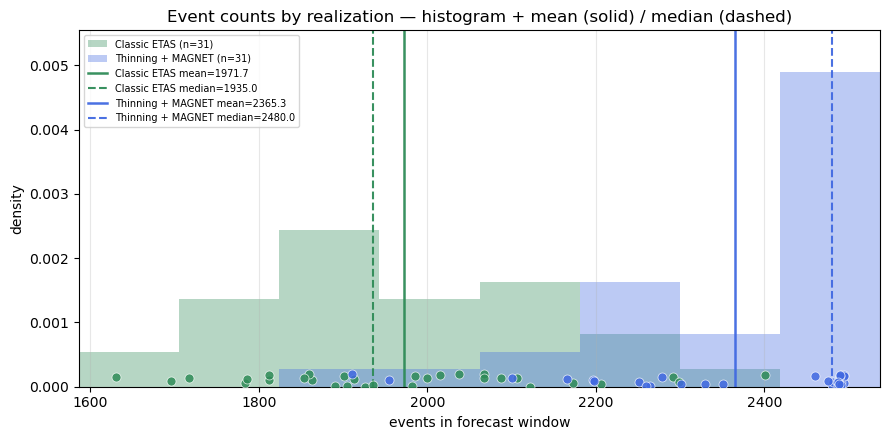

In [57]:
paired_metrics = pd.DataFrame({"seed": selected_seeds})

for method, catalogs in catalogs_by_method.items():
    for seed in selected_seeds:
        cat = catalogs[seed]
        row_mask = paired_metrics["seed"] == seed
        paired_metrics.loc[row_mask, f"{method}_n_events"] = len(cat)
        paired_metrics.loc[row_mask, f"{method}_max_magnitude"] = (
            float(cat["m"].max()) if len(cat) else np.nan
        )
        paired_metrics.loc[row_mask, f"{method}_median_iet_days"] = median_interevent_days(cat)
        if "event_source" in cat.columns:
            for sub in ("background", "triggered"):
                paired_metrics.loc[row_mask, f"{method}_{sub}"] = int(
                    (cat["event_source"] == sub).sum()
                )
            n = paired_metrics.loc[row_mask, f"{method}_n_events"].values[0]
            paired_metrics.loc[row_mask, f"{method}_bg_frac"] = (
                paired_metrics.loc[row_mask, f"{method}_background"].values[0] / n
                if n
                else np.nan
            )

display(Markdown("**Per-realization metrics:**"))
display(paired_metrics)

# Event-count distributions: points + hist/KDE + scalar vertical lines
_HIST_MIN_REALIZATIONS = 15
count_by_method = {
    method: paired_metrics[f"{method}_n_events"].to_numpy(dtype=float)
    for method in methods
}
all_counts = np.concatenate(list(count_by_method.values())) if count_by_method else np.array([])
if all_counts.size == 0:
    display(Markdown("_No event counts to plot._"))
else:
    x_lo = float(np.nanmin(all_counts))
    x_hi = float(np.nanmax(all_counts))
    x_pad = max(0.05 * (x_hi - x_lo), 1.0)
    x_lo, x_hi = x_lo - x_pad, x_hi + x_pad
    x_grid = np.linspace(x_lo, x_hi, 400)

    fig, ax = plt.subplots(figsize=(9, 4.5))
    rng_jitter = np.random.default_rng(0)
    use_hist = all(len(v) >= _HIST_MIN_REALIZATIONS for v in count_by_method.values())
    n_bins = max(8, min(30, int(np.sqrt(max(len(v) for v in count_by_method.values())))))

    for method in methods:
        counts = count_by_method[method]
        color = METHOD_COLORS[method]
        label = METHOD_LABELS[method]
        n = len(counts)
        if n == 0:
            continue
        if use_hist:
            ax.hist(
                counts,
                bins=n_bins,
                range=(x_lo, x_hi),
                density=True,
                alpha=0.35,
                color=color,
                label=f"{label} (n={n})",
            )
        elif n >= 2 and float(np.nanstd(counts)) > 0:
            kde = stats.gaussian_kde(counts)
            ax.plot(x_grid, kde(x_grid), color=color, lw=2.0, label=f"{label} KDE (n={n})")
        else:
            ax.plot([], [], color=color, lw=2.0, label=f"{label} (n={n})")

    # Realization points as a rug on the count axis
    ymax = max(ax.get_ylim()[1], 1e-6)
    rug_amp = 0.04 * ymax
    for method in methods:
        counts = count_by_method[method]
        if len(counts) == 0:
            continue
        color = METHOD_COLORS[method]
        y = rng_jitter.uniform(0.0, rug_amp, size=len(counts))
        ax.scatter(
            counts,
            y,
            color=color,
            s=42,
            alpha=0.85,
            zorder=5,
            edgecolors="white",
            linewidths=0.5,
        )
        mean_n = float(np.nanmean(counts))
        median_n = float(np.nanmedian(counts))
        ax.axvline(
            mean_n,
            color=color,
            ls="-",
            lw=1.8,
            alpha=0.95,
            label=f"{METHOD_LABELS[method]} mean={mean_n:.1f}",
        )
        ax.axvline(
            median_n,
            color=color,
            ls="--",
            lw=1.5,
            alpha=0.95,
            label=f"{METHOD_LABELS[method]} median={median_n:.1f}",
        )

    ax.set_xlim(x_lo, x_hi)
    ax.set_ylim(0.0, ymax * 1.08)
    ax.set_xlabel("events in forecast window")
    ax.set_ylabel("density")
    ax.set_title(
        f"Event counts by realization — "
        f"{'histogram' if use_hist else 'KDE'} + mean (solid) / median (dashed)"
    )
    ax.grid(True, alpha=0.3, axis="x")
    ax.legend(fontsize=7, loc="best")
    fig.tight_layout()
    show_fig(fig)


## Tier 1 — cumulative count and rate


  Rounding issues found. Check if delta_m and mc_current are set correctly.
/tmp/ipykernel_3012179/3471791306.py:89: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


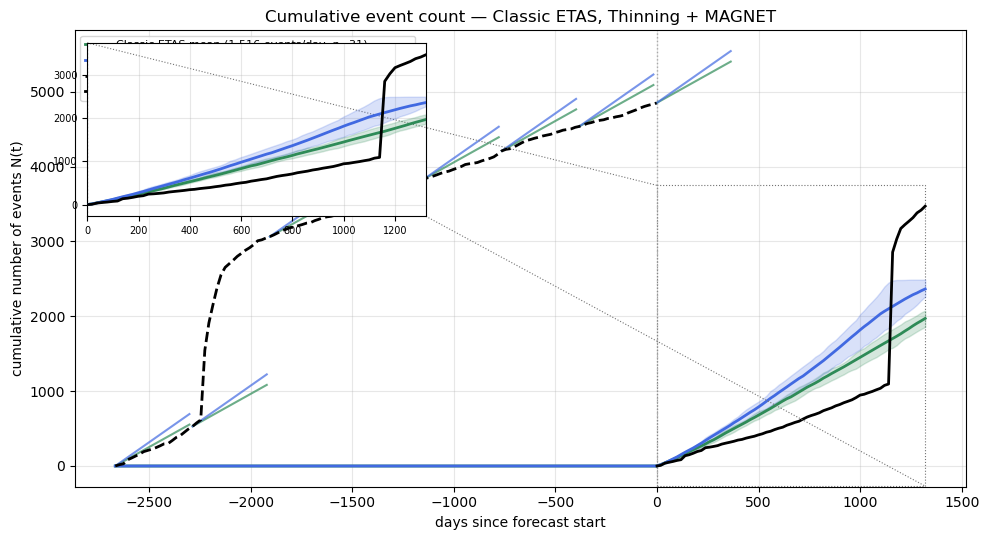

/tmp/ipykernel_3012179/3471791306.py:146: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


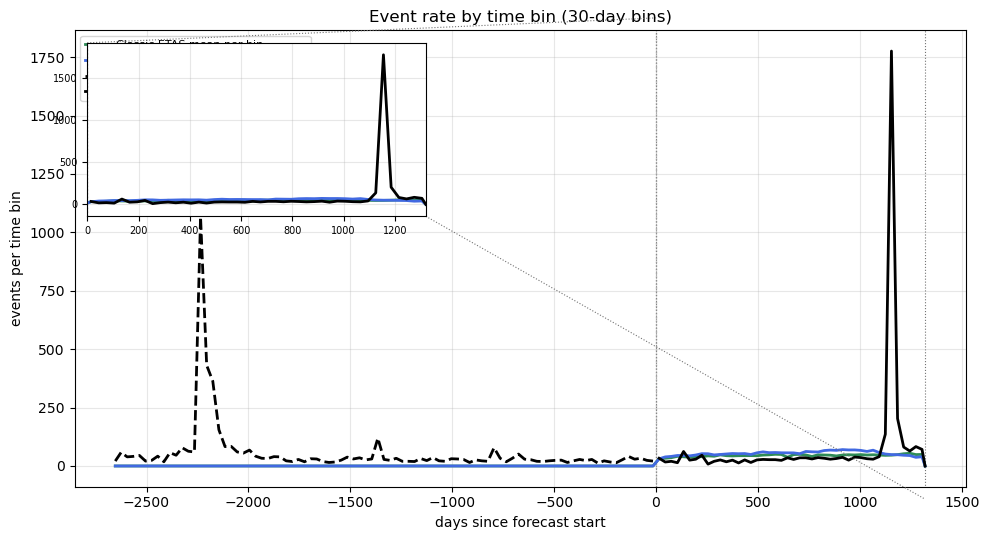

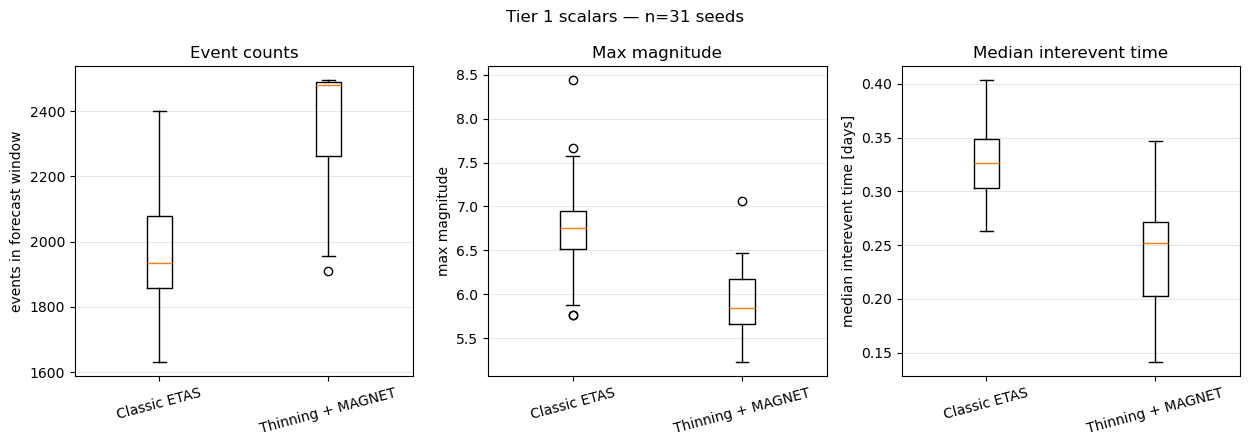

In [58]:
try:
    ctx = load_intensity_context(OUTPUT_ROOT, primary_dir, primary_meta, selected_seeds[0])
    mc_val = float(ctx["mc"])
    beta_val = float(ctx["beta"])
    forecast_days = float(ctx["forecast_days"])
    actual_test_dt_days = ctx["actual_test_dt_days"]
    actual_test_m = ctx["actual_test_m"]
    timewindow_start = ctx.get("timewindow_start")
    timewindow_end = ctx.get("timewindow_end")
    train_dt_days = np.array([], dtype=float)
    train_days = 0.0
    if timewindow_start and timewindow_end:
        train_start_dt = pd.to_datetime(timewindow_start, utc=True).tz_convert(None)
        train_end_dt = pd.to_datetime(timewindow_end, utc=True).tz_convert(None)
        train_df = ctx["history_df"].loc[
            (ctx["history_df"]["time"] >= train_start_dt)
            & (ctx["history_df"]["time"] <= train_end_dt)
        ]
        train_dt_days = train_df["t"].to_numpy(dtype=float) - ctx["forecast_start_t"]
        train_days = float((train_end_dt - train_start_dt).total_seconds() / 86400.0)
except Exception as exc:
    display(Markdown(f"_Could not load inversion context ({exc}); using catalog times only._"))
    all_dt = np.concatenate(
        [cat["dt_days"].to_numpy() for catalogs in catalogs_by_method.values() for cat in catalogs.values()]
    )
    forecast_days = float(np.nanmax(all_dt)) if all_dt.size else 1.0
    train_dt_days = np.array([], dtype=float)
    actual_test_dt_days = np.array([], dtype=float)
    actual_test_m = np.array([], dtype=float)
    train_days = 0.0
    mc_val = float("nan")
    beta_val = float("nan")

t_grid = np.linspace(-train_days, forecast_days, 200)
curves_by_method = {
    method: np.vstack(
        [cumulative_on_grid(catalogs[s]["dt_days"].to_numpy(), t_grid) for s in selected_seeds]
    )
    for method, catalogs in catalogs_by_method.items()
}
forecast_mask = t_grid >= 0.0
slopes_by_method = {
    method: float(np.polyfit(t_grid[forecast_mask], arr.mean(axis=0)[forecast_mask], 1)[0])
    for method, arr in curves_by_method.items()
}

cum_ylim_curves = [arr.mean(axis=0) for arr in curves_by_method.values()]
for arr in curves_by_method.values():
    if arr.shape[0] > 1:
        q25, q75 = np.quantile(arr, [0.25, 0.75], axis=0)
        cum_ylim_curves.extend([q25, q75])
if actual_test_dt_days.size:
    cum_ylim_curves.append(cumulative_on_grid(actual_test_dt_days, t_grid))
cum_test_ylims = ylim_in_xrange(t_grid, cum_ylim_curves, 0.0, forecast_days)

fig, ax = plt.subplots(figsize=(10, 5.5))
draw_cumulative_event_count(
    ax,
    t_grid=t_grid,
    curves_by_method=curves_by_method,
    slopes_by_method=slopes_by_method,
    train_dt_days=train_dt_days,
    actual_test_dt_days=actual_test_dt_days,
    train_days=train_days,
    show_training_slopes=True,
    show_legend=True,
)
ax.set_xlabel("days since forecast start")
ax.set_ylabel("cumulative number of events N(t)")
ax.set_title(f"Cumulative event count — {', '.join(METHOD_LABELS[m] for m in methods)}")
ax.grid(True, alpha=0.3)
ax.legend(fontsize=8)
add_test_window_inset(
    ax,
    forecast_days,
    lambda axins: draw_cumulative_event_count(
        axins,
        t_grid=t_grid,
        curves_by_method=curves_by_method,
        slopes_by_method=slopes_by_method,
        train_dt_days=train_dt_days,
        actual_test_dt_days=actual_test_dt_days,
        train_days=train_days,
        show_training_slopes=False,
        show_legend=False,
    ),
    ylims=cum_test_ylims,
)
fig.tight_layout()
show_fig(fig)

BIN_LENGTH_DAYS = 30.0
t_min, t_max = -train_days, forecast_days
negative_edges = -np.arange(0.0, train_days + BIN_LENGTH_DAYS, BIN_LENGTH_DAYS)[::-1]
negative_edges = negative_edges[negative_edges >= t_min]
if negative_edges.size == 0 or negative_edges[0] > t_min:
    negative_edges = np.insert(negative_edges, 0, t_min)
positive_edges = np.arange(0.0, forecast_days + BIN_LENGTH_DAYS, BIN_LENGTH_DAYS)
positive_edges = positive_edges[positive_edges <= t_max]
if positive_edges.size == 0 or positive_edges[-1] < t_max:
    positive_edges = np.append(positive_edges, t_max)
bin_edges = np.unique(np.concatenate((negative_edges, positive_edges)))
bin_centers = 0.5 * (bin_edges[:-1] + bin_edges[1:])
bin_curves_by_method = {
    method: np.vstack(
        [events_per_time_bin(catalogs[s]["dt_days"].to_numpy(), bin_edges) for s in selected_seeds]
    )
    for method, catalogs in catalogs_by_method.items()
}
bin_means = [arr.mean(axis=0) for arr in bin_curves_by_method.values()]
if actual_test_dt_days.size:
    bin_means.append(events_per_time_bin(actual_test_dt_days, bin_edges))
bin_test_ylims = ylim_in_xrange(bin_centers, bin_means, 0.0, forecast_days)

fig, ax = plt.subplots(figsize=(10, 5.5))
draw_event_rate_by_bin(
    ax,
    bin_centers=bin_centers,
    bin_edges=bin_edges,
    bin_curves_by_method=bin_curves_by_method,
    train_dt_days=train_dt_days,
    actual_test_dt_days=actual_test_dt_days,
    include_training=True,
    show_legend=True,
)
ax.set_xlabel("days since forecast start")
ax.set_ylabel("events per time bin")
ax.set_title(f"Event rate by time bin ({BIN_LENGTH_DAYS:g}-day bins)")
ax.grid(True, alpha=0.3)
ax.legend(fontsize=8)
add_test_window_inset(
    ax,
    forecast_days,
    lambda axins: draw_event_rate_by_bin(
        axins,
        bin_centers=bin_centers,
        bin_edges=bin_edges,
        bin_curves_by_method=bin_curves_by_method,
        train_dt_days=train_dt_days,
        actual_test_dt_days=actual_test_dt_days,
        include_training=False,
        show_legend=False,
    ),
    ylims=bin_test_ylims,
)
fig.tight_layout()
show_fig(fig)

# Scalar boxplots
n_panels = 3
fig, axes = plt.subplots(1, n_panels, figsize=(4.2 * n_panels, 4.5))
count_series = [paired_metrics[f"{m}_n_events"] for m in methods]
axes[0].boxplot(count_series, tick_labels=[METHOD_LABELS[m] for m in methods])
axes[0].set_ylabel("events in forecast window")
axes[0].set_title("Event counts")
axes[0].tick_params(axis="x", rotation=15)
axes[0].grid(True, alpha=0.3, axis="y")

max_m_series = [paired_metrics[f"{m}_max_magnitude"] for m in methods]
axes[1].boxplot(max_m_series, tick_labels=[METHOD_LABELS[m] for m in methods])
axes[1].set_ylabel("max magnitude")
axes[1].set_title("Max magnitude")
axes[1].tick_params(axis="x", rotation=15)
axes[1].grid(True, alpha=0.3, axis="y")

iet_series = [paired_metrics[f"{m}_median_iet_days"] for m in methods]
axes[2].boxplot(iet_series, tick_labels=[METHOD_LABELS[m] for m in methods])
axes[2].set_ylabel("median interevent time [days]")
axes[2].set_title("Median interevent time")
axes[2].tick_params(axis="x", rotation=15)
axes[2].grid(True, alpha=0.3, axis="y")

fig.suptitle(f"Tier 1 scalars — n={len(selected_seeds)} seeds", fontsize=12)
fig.tight_layout()
show_fig(fig)


## Tier 2 — pooled magnitude and interevent-time distributions


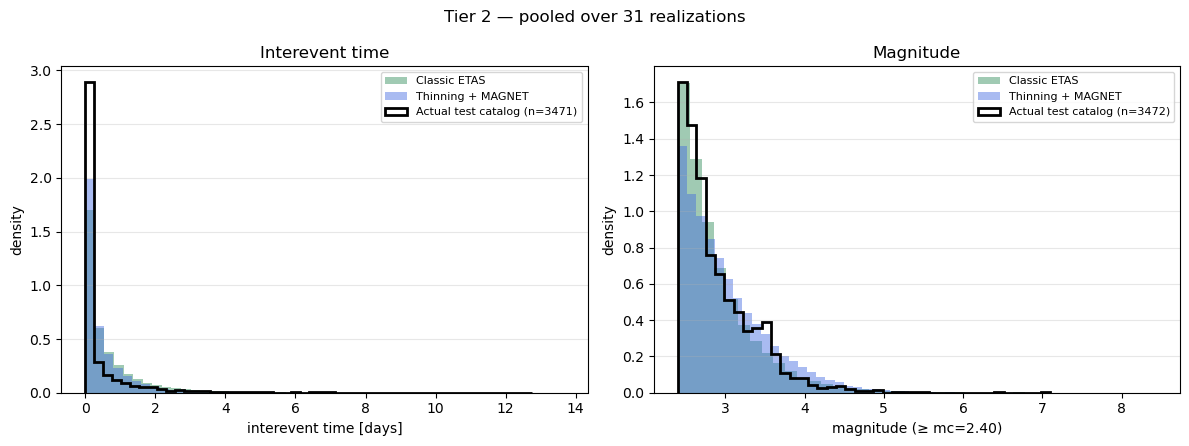

**Tier 2 — pairwise KS tests:**

,comparison,quantity,KS statistic,p-value
0,Classic ETAS vs Thinning + MAGNET,interevent time,0.071689,2.387200e-149
1,Classic ETAS vs Thinning + MAGNET,magnitude,0.106592,0.000000e+00


In [59]:
pooled_iet = {
    method: np.concatenate(
        [interevent_times(catalogs[s]["dt_days"].to_numpy(dtype=float)) for s in selected_seeds]
    )
    for method, catalogs in catalogs_by_method.items()
}
pooled_m = {}
for method, catalogs in catalogs_by_method.items():
    m_all = np.concatenate([catalogs[s]["m"].to_numpy(dtype=float) for s in selected_seeds])
    if np.isfinite(mc_val):
        m_all = m_all[m_all >= mc_val]
    pooled_m[method] = m_all

test_iet = interevent_times(np.asarray(actual_test_dt_days, dtype=float))
test_m = np.asarray(actual_test_m, dtype=float)
if np.isfinite(mc_val) and test_m.size:
    test_m = test_m[test_m >= mc_val]

_IET_BINS = 50
_MAG_BINS = 40
_TEST_HIST_KW = {
    "density": True,
    "histtype": "step",
    "linewidth": 2.0,
    "color": "black",
    "zorder": 5,
}

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
for method in methods:
    if pooled_iet[method].size:
        axes[0].hist(
            pooled_iet[method],
            bins=_IET_BINS,
            density=True,
            alpha=0.45,
            color=METHOD_COLORS[method],
            label=METHOD_LABELS[method],
        )
    if pooled_m[method].size:
        axes[1].hist(
            pooled_m[method],
            bins=_MAG_BINS,
            density=True,
            alpha=0.45,
            color=METHOD_COLORS[method],
            label=METHOD_LABELS[method],
        )
if test_iet.size:
    axes[0].hist(
        test_iet,
        bins=_IET_BINS,
        label=f"Actual test catalog (n={test_iet.size})",
        **_TEST_HIST_KW,
    )
if test_m.size:
    axes[1].hist(
        test_m,
        bins=_MAG_BINS,
        label=f"Actual test catalog (n={test_m.size})",
        **_TEST_HIST_KW,
    )
axes[0].set_xlabel("interevent time [days]")
axes[0].set_ylabel("density")
axes[0].set_title("Interevent time")
axes[0].legend(fontsize=8)
axes[0].grid(True, alpha=0.3, axis="y")
axes[1].set_xlabel(f"magnitude (≥ mc={mc_val:.2f})" if np.isfinite(mc_val) else "magnitude")
axes[1].set_ylabel("density")
axes[1].set_title("Magnitude")
axes[1].legend(fontsize=8)
axes[1].grid(True, alpha=0.3, axis="y")
fig.suptitle(f"Tier 2 — pooled over {len(selected_seeds)} realizations", fontsize=12)
fig.tight_layout()
show_fig(fig)

if len(methods) >= 2:
    ks_rows = []
    for i, ma in enumerate(methods):
        for mb in methods[i + 1 :]:
            for name, store in [("interevent time", pooled_iet), ("magnitude", pooled_m)]:
                a_data, b_data = store[ma], store[mb]
                if a_data.size and b_data.size:
                    stat, pval = stats.ks_2samp(a_data, b_data)
                    ks_rows.append(
                        {
                            "comparison": f"{METHOD_LABELS[ma]} vs {METHOD_LABELS[mb]}",
                            "quantity": name,
                            "KS statistic": stat,
                            "p-value": pval,
                        }
                    )
    display(Markdown("**Tier 2 — pairwise KS tests:**"))
    display(pd.DataFrame(ks_rows))


## Formal tests (when ≥ 2 methods)


In [60]:
if len(methods) < 2:
    display(Markdown("_Fewer than 2 methods — skip paired formal tests._"))
else:
    formal_rows = []
    n_perm = 5000
    rng = np.random.default_rng(0)
    for i, ma in enumerate(methods):
        for mb in methods[i + 1 :]:
            a_counts = paired_metrics[f"{ma}_n_events"].to_numpy(dtype=float)
            b_counts = paired_metrics[f"{mb}_n_events"].to_numpy(dtype=float)
            paired_diff = b_counts - a_counts
            if len(selected_seeds) >= 2 and np.any(paired_diff != 0):
                w_stat, w_p = stats.wilcoxon(b_counts, a_counts)
            else:
                w_stat, w_p = np.nan, np.nan
            if len(selected_seeds) >= 2:
                pr, pp = stats.pearsonr(a_counts, b_counts)
            else:
                pr, pp = np.nan, np.nan
            obs = float(paired_diff.mean())
            perm = np.empty(n_perm)
            for k in range(n_perm):
                signs = rng.choice([-1.0, 1.0], size=len(paired_diff))
                perm[k] = (signs * paired_diff).mean()
            perm_p = float((np.abs(perm) >= abs(obs)).mean())
            label = f"{METHOD_LABELS[ma]} vs {METHOD_LABELS[mb]}"
            formal_rows.extend(
                [
                    {"pair": label, "test": "Paired Wilcoxon (counts)", "statistic": w_stat, "p-value": w_p},
                    {"pair": label, "test": "Pearson r (counts)", "statistic": pr, "p-value": pp},
                    {"pair": label, "test": "Permutation mean Δcount", "statistic": obs, "p-value": perm_p},
                ]
            )
    display(Markdown("**Formal tests:**"))
    display(pd.DataFrame(formal_rows))


**Formal tests:**

,pair,test,statistic,p-value
0,Classic ETAS vs Thinning + MAGNET,Paired Wilcoxon (counts),14.000000,1.024455e-07
1,Classic ETAS vs Thinning + MAGNET,Pearson r (counts),-0.116824,5.314028e-01
2,Classic ETAS vs Thinning + MAGNET,Permutation mean Δcount,393.516129,0.000000e+00


## MAGNET Kumaraswamy forecast samples

Shown only when `thinning_magnet` is loaded **and** a `magnet_predictions.npz` sidecar
exists for the chosen seed (enable with `magnet.save_predictions` or
`--save-magnet-predictions` in `run_continuation_models.py`).

Control which events to plot via the **User config** cell:

| Setting | Meaning |
|---|---|
| `MAGNET_PRED_SEED` | Realization seed (`None` → first seed with a sidecar) |
| `SHOW_ACTUAL_CONTINUATION` | Overlay observed catalog in the continuation window on the mag–time scatter |
| `MAGNET_SCATTER_INTERACTIVE` | Plotly zoom/pan for the mag–time scatter (`False` → static matplotlib) |
| `KUMA_EVENT_MODE` | `indices` / `largest_m` / `first_n` / `magnitude_range` |
| `KUMA_EVENT_INDICES` | Explicit 0-based row indices (when mode=`indices`) |
| `KUMA_N_EVENTS` | How many PDFs to draw |
| `KUMA_MAG_RANGE` | Magnitude window for `magnitude_range` |

Row index `i` refers to the `i`-th entry in `magnet_predictions.npz` (aligned with
forecast order; `event_index` in the sidecar may be constant when MAGNET is called
one event at a time).


**MAGNET predictions:** seed `0` → `/home/neriberman/Repos/etas/outputs/hauksson_magnet_sample_continuation_models/thinning_magnet/inv_adfc87cc569b6091/seed_0/magnet_predictions.npz` (2500 rows)

PDF support: shift (mc) = `2.4`, stretch = `7.0`

**Selected events** (`largest_m`): `[0, 4, 22, 108, 522, 2499]` — magnitudes `[2.4, 2.618, 3.001, 2.795, 2.502, 3.325]`

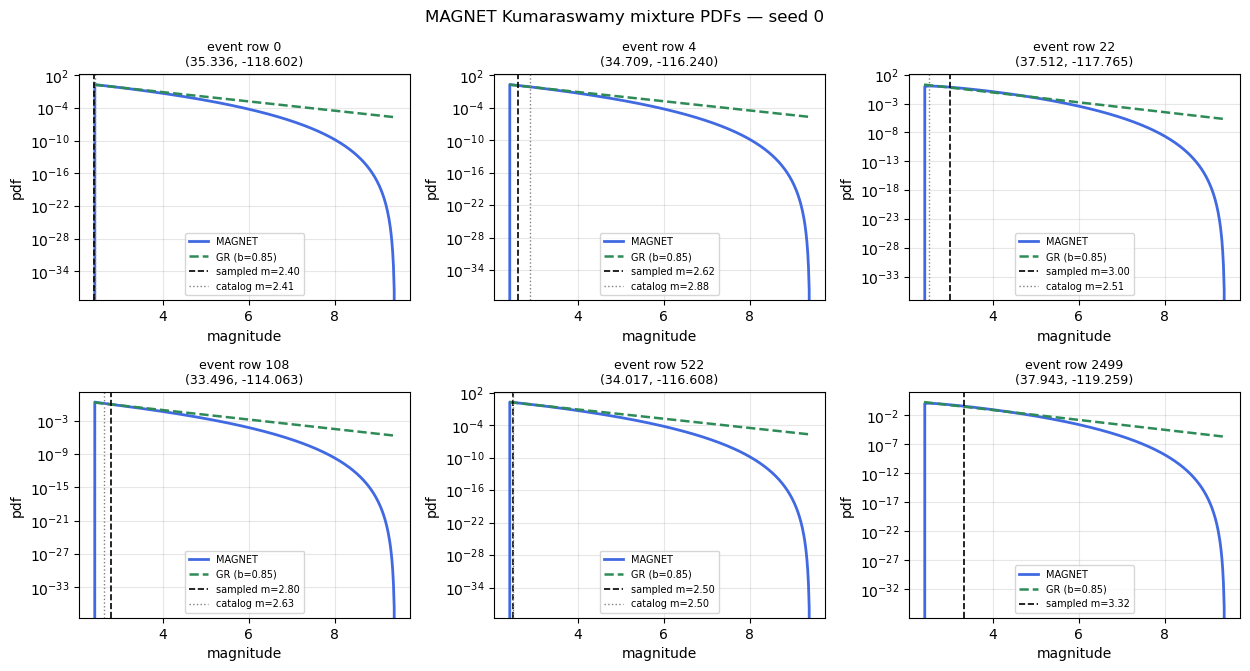

**Selected events (set `KUMA_EVENT_MODE='indices'` + `KUMA_EVENT_INDICES` to lock these):**

,row,magnitude,latitude,longitude,time_unix
0,0,2.400013,35.336296,-118.602201,1463867159
1,4,2.617649,34.708819,-116.240159,1464146274
2,22,3.000789,37.512103,-117.765309,1465110822
3,108,2.795000,33.496032,-114.062957,1473262409
4,522,2.502277,34.017422,-116.607691,1500832154
5,2499,3.324644,37.942546,-119.259165,1551233253


In [61]:
HAS_MAGNET = "thinning_magnet" in catalogs_by_method
magnet_preds = None
magnet_seed_used = None
magnet_run_dir = None

if not HAS_MAGNET:
    display(Markdown("_`thinning_magnet` not in methods — skip Kumaraswamy samples._"))
else:
    magnet_dir = ensemble_dirs["thinning_magnet"]
    candidate_seeds = (
        [MAGNET_PRED_SEED] if MAGNET_PRED_SEED is not None else list(selected_seeds)
    )
    for seed in candidate_seeds:
        run_dir = realization_dir(magnet_dir, seed)
        preds = load_magnet_predictions(run_dir)
        if preds is not None:
            magnet_preds = preds
            magnet_seed_used = seed
            magnet_run_dir = run_dir
            break

    if magnet_preds is None:
        display(Markdown(
            f"_No `{_MAGNET_PREDICTIONS_NAME}` under `{magnet_dir}` for seeds "
            f"{candidate_seeds}. Re-run with `--save-magnet-predictions`._"
        ))
    else:
        display(Markdown(
            f"**MAGNET predictions:** seed `{magnet_seed_used}` → `{magnet_run_dir / _MAGNET_PREDICTIONS_NAME}` "
            f"({len(magnet_preds['magnitude'])} rows)"
        ))

        mag_meta = metas_by_method["thinning_magnet"]
        model_dir = Path(mag_meta["thinning_model_dir"]) if mag_meta.get("thinning_model_dir") else None
        shift, stretch = parse_magnet_shift_stretch(model_dir, mc_val)
        display(Markdown(f"PDF support: shift (mc) = `{shift}`, stretch = `{stretch}`"))

        mags = np.asarray(magnet_preds["magnitude"], dtype=float)
        preds_arr = np.asarray(magnet_preds["model_prediction"])
        _kuma_n_panels = 6
        _kuma_log_indices = np.unique(
            np.round(np.geomspace(1, len(mags), num=_kuma_n_panels)).astype(int) - 1
        ).tolist()
        event_ids = select_kuma_event_indices(
            mags,
            mode='indices',
            indices=_kuma_log_indices,
            n_events=100,
            mag_range=[0,10],
        )
        # event_ids = select_kuma_event_indices(
        #     mags,
        #     mode=KUMA_EVENT_MODE,
        #     indices=KUMA_EVENT_INDICES,
        #     n_events=KUMA_N_EVENTS,
        #     mag_range=KUMA_MAG_RANGE,
        # )
        display(Markdown(
            f"**Selected events** (`{KUMA_EVENT_MODE}`): `{event_ids}` — "
            f"magnitudes `{[round(float(mags[i]), 3) for i in event_ids]}`"
        ))

        # Catalog alignment for annotation (npz may be longer if truncated mid-run).
        catalog = catalogs_by_method["thinning_magnet"][magnet_seed_used]
        n_align = min(len(catalog), len(mags))

        if KUMA_M_GRID is None:
            m_lo = float(shift)
            m_hi = float(shift + stretch)
            n_grid = 400
        else:
            m_lo, m_hi, n_grid = KUMA_M_GRID
        m_grid = np.linspace(m_lo, m_hi, int(n_grid))
        gr_pdf = (
            beta_val * np.exp(-beta_val * (m_grid - shift))
            if np.isfinite(beta_val) and beta_val > 0
            else None
        )

        n_show = len(event_ids)
        n_cols = min(3, max(1, n_show))
        n_rows = int(math.ceil(n_show / n_cols)) if n_show else 1
        fig, axes = plt.subplots(n_rows, n_cols, figsize=(4.2 * n_cols, 3.4 * n_rows), squeeze=False)
        for ax in axes.ravel():
            ax.set_visible(False)

        for panel_i, event_i in enumerate(event_ids):
            ax = axes[panel_i // n_cols][panel_i % n_cols]
            ax.set_visible(True)
            pred_row = preds_arr[event_i]
            pdf = magnitude_pdf_from_prediction(m_grid, pred_row, shift=shift, stretch=stretch)
            ax.plot(
                m_grid,
                pdf,
                color=METHOD_COLORS["thinning_magnet"],
                lw=2.0,
                label="MAGNET",
            )
            if gr_pdf is not None:
                b_value = beta_val / np.log(10.0)
                ax.plot(
                    m_grid,
                    gr_pdf,
                    color=METHOD_COLORS.get("etas", "tab:blue"),
                    ls="--",
                    lw=1.8,
                    label=f"GR (b={b_value:.2f})",
                )
            sampled_m = float(mags[event_i])
            ax.axvline(sampled_m, color="black", ls="--", lw=1.2, label=f"sampled m={sampled_m:.2f}")
            if event_i < n_align:
                cat_m = float(catalog.iloc[event_i]["m"])
                if abs(cat_m - sampled_m) > 1e-3:
                    ax.axvline(cat_m, color="gray", ls=":", lw=1.0, label=f"catalog m={cat_m:.2f}")
            lon = float(magnet_preds["longitude"][event_i])
            lat = float(magnet_preds["latitude"][event_i])
            ax.set_title(f"event row {event_i}\n({lat:.3f}, {lon:.3f})", fontsize=9)
            ax.set_xlabel("magnitude")
            ax.set_ylabel("pdf")
            ax.set_yscale("log")
            ax.grid(True, alpha=0.3, which="both")
            ax.legend(fontsize=7)

        fig.suptitle(
            f"MAGNET Kumaraswamy mixture PDFs — seed {magnet_seed_used}",
            fontsize=12,
        )
        fig.tight_layout()
        show_fig(fig)

        # Table of selected events for easy re-selection via KUMA_EVENT_INDICES
        rows = []
        for event_i in event_ids:
            rows.append(
                {
                    "row": event_i,
                    "magnitude": float(mags[event_i]),
                    "latitude": float(magnet_preds["latitude"][event_i]),
                    "longitude": float(magnet_preds["longitude"][event_i]),
                    "time_unix": int(magnet_preds["time"][event_i]),
                    "pred_params": np.asarray(preds_arr[event_i]).tolist(),
                }
            )
        display(Markdown("**Selected events (set `KUMA_EVENT_MODE='indices'` + `KUMA_EVENT_INDICES` to lock these):**"))
        display(pd.DataFrame(rows).drop(columns=["pred_params"]))


## MAGNET Kumaraswamy parameters vs time

For the **same realization** used in the Kumaraswamy PDF panels above (`magnet_seed_used`),
plot mixture parameters (`a[k]`, `b[k]`, `w[k]` for each component `k`) vs event time.

Tune `MAGNET_PARAMS_EVENT_STRIDE` to thin dense catalogs.

**Kumaraswamy parameters:** seed `0`, 2 component(s), 2500 events

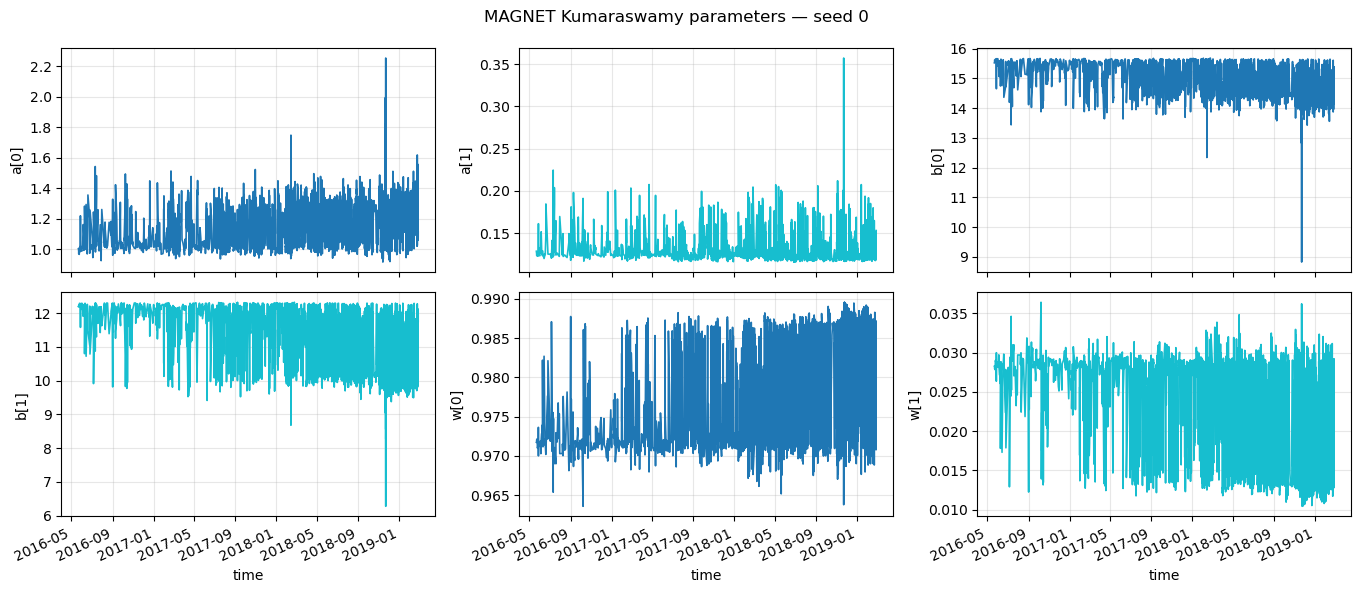

In [62]:
if magnet_seed_used is None or magnet_preds is None:
    display(Markdown("_No MAGNET realization selected above — skip parameter time series._"))
else:
    n_events = len(magnet_preds["magnitude"])
    n_comp = int(np.asarray(magnet_preds["model_prediction"]).shape[-1] // 3)
    display(Markdown(
        f"**Kumaraswamy parameters:** seed `{magnet_seed_used}`, "
        f"{n_comp} component(s), {n_events} events"
    ))
    fig = plot_kumaraswamy_params_vs_time(
        magnet_preds,
        event_stride=MAGNET_PARAMS_EVENT_STRIDE,
        title=f"MAGNET Kumaraswamy parameters — seed {magnet_seed_used}",
    )
    if fig is not None:
        show_fig(fig)


## MAGNET realization — magnitude vs time

Same seed as the Kumaraswamy PDF panels above (`magnet_seed_used`). One **stacked subplot per method** loaded in this run (shared date axis), each showing the pre-continuation catalog, simulated continuation, and optionally the observed continuation (`SHOW_ACTUAL_CONTINUATION`). PDF event highlights appear on the `thinning_magnet` panel only.

With `MAGNET_SCATTER_INTERACTIVE=True` (default), this cell renders an **interactive Plotly** figure (box-zoom / double-click reset). Set it to `False` for static matplotlib.


In [63]:
if magnet_seed_used is None or magnet_preds is None:
    display(Markdown("_No MAGNET realization selected above — skip magnitude–time scatter._"))
else:
    def _catalog_times_and_mags(catalog: pd.DataFrame, forecast_start: pd.Timestamp | None):
        mags = catalog["m"].to_numpy(dtype=float)
        if "time" in catalog.columns:
            times = pd.to_datetime(catalog["time"], utc=True).dt.tz_convert(None)
        elif "dt_days" in catalog.columns and forecast_start is not None:
            times = forecast_start + pd.to_timedelta(
                catalog["dt_days"].to_numpy(dtype=float),
                unit="D",
            )
        else:
            raise ValueError(
                "forecast catalog missing 'time' (and no forecast_start for dt_days)"
            )
        return times, mags

    def _pick_times(times, indices):
        if hasattr(times, "iloc"):
            return times.iloc[indices]
        return times[indices]

    # Pre-continuation + optional observed continuation from intensity context.
    hist_times = pd.Series(dtype="datetime64[ns]")
    hist_m = np.array([], dtype=float)
    actual_times = pd.Series(dtype="datetime64[ns]")
    actual_m = np.array([], dtype=float)
    forecast_start_dt = None
    try:
        _ctx = ctx if "ctx" in globals() and isinstance(ctx, dict) and "history_df" in ctx else None
        if _ctx is None:
            _ctx = load_intensity_context(
                OUTPUT_ROOT,
                ensemble_dirs["thinning_magnet"],
                metas_by_method["thinning_magnet"],
                magnet_seed_used,
            )
        history_df = _ctx["history_df"]
        forecast_start_t = float(_ctx["forecast_start_t"])
        forecast_start_dt = pd.Timestamp("1970-01-01") + pd.to_timedelta(forecast_start_t, unit="D")
        tw_start = _ctx.get("timewindow_start")
        tw_end = _ctx.get("timewindow_end")
        hist = history_df
        if tw_start and tw_end:
            train_start_dt = pd.to_datetime(tw_start, utc=True).tz_convert(None)
            train_end_dt = pd.to_datetime(tw_end, utc=True).tz_convert(None)
            hist = history_df.loc[
                (history_df["time"] >= train_start_dt) & (history_df["time"] <= train_end_dt)
            ]
            forecast_start_dt = train_end_dt
        hist_times = pd.to_datetime(hist["time"], utc=True).dt.tz_convert(None)
        hist_m = hist["magnitude"].to_numpy(dtype=float)
        if SHOW_ACTUAL_CONTINUATION:
            actual_dt_days = np.asarray(_ctx.get("actual_test_dt_days", []), dtype=float)
            actual_m = np.asarray(_ctx.get("actual_test_m", []), dtype=float)
            if (
                actual_dt_days.size
                and actual_m.size == actual_dt_days.size
                and forecast_start_dt is not None
            ):
                actual_times = forecast_start_dt + pd.to_timedelta(actual_dt_days, unit="D")
            elif actual_dt_days.size and actual_m.size == 0:
                display(Markdown(
                    "_`SHOW_ACTUAL_CONTINUATION=True` but `actual_test_m` missing — "
                    "re-run the helpers cell to refresh `load_intensity_context`._"
                ))
    except Exception as exc:
        display(Markdown(f"_Could not load pre-continuation / observed catalog ({exc})._"))

    method_layers: dict[str, tuple[pd.Series | pd.DatetimeIndex, np.ndarray]] = {}
    for method in methods:
        method_catalogs = catalogs_by_method.get(method, {})
        if magnet_seed_used not in method_catalogs:
            continue
        method_layers[method] = _catalog_times_and_mags(
            method_catalogs[magnet_seed_used],
            forecast_start_dt,
        )
    if not method_layers:
        raise ValueError(f"No forecast catalogs loaded for seed {magnet_seed_used}")

    magnet_cat = catalogs_by_method["thinning_magnet"][magnet_seed_used]
    highlight_ids = list(event_ids) if "event_ids" in globals() and event_ids else []
    highlight_ids = [i for i in highlight_ids if 0 <= i < len(magnet_cat)]
    idx_step = 500
    magnet_times, _ = method_layers["thinning_magnet"]
    idx_ticks = list(range(0, len(magnet_cat), idx_step))
    method_part = ", ".join(METHOD_LABELS[m] for m in method_layers)
    title = (
        f"Magnitude vs time — seed {magnet_seed_used} ({method_part})"
        + (" + observed" if SHOW_ACTUAL_CONTINUATION else "")
    )

    def _draw_method_panel(
        ax,
        method: str,
        cont_times,
        cont_mags: np.ndarray,
        *,
        show_xlabel: bool,
        show_idx_axis: bool,
    ):
        import matplotlib.dates as mdates

        if len(hist_times):
            ax.scatter(
                hist_times,
                hist_m,
                s=14,
                alpha=0.2,
                color="0.45",
                edgecolors="none",
                label=f"pre-continuation (n={len(hist_times)})",
                zorder=1,
            )
        if SHOW_ACTUAL_CONTINUATION and len(actual_times) and actual_m.size == len(actual_times):
            ax.scatter(
                actual_times,
                actual_m,
                s=22,
                alpha=0.3,
                color="darkorange",
                edgecolors="none",
                marker="D",
                label=f"observed continuation (n={len(actual_times)})",
                zorder=2,
            )
        ax.scatter(
            cont_times,
            cont_mags,
            s=22,
            alpha=0.7,
            color=METHOD_COLORS[method],
            edgecolors="none",
            label=f"continuation seed {magnet_seed_used} (n={len(cont_mags)})",
            zorder=3,
        )
        if method == "thinning_magnet" and highlight_ids:
            ax.scatter(
                _pick_times(cont_times, highlight_ids),
                cont_mags[highlight_ids],
                s=90,
                facecolors="none",
                edgecolors="black",
                linewidths=1.4,
                label=f"PDF panels ({len(highlight_ids)})",
                zorder=4,
            )
            for i in highlight_ids:
                ax.annotate(
                    str(i),
                    (mdates.date2num(_pick_times(cont_times, [i])[0]), cont_mags[i]),
                    textcoords="offset points",
                    xytext=(4, 4),
                    fontsize=8,
                    zorder=5,
                )
        if forecast_start_dt is not None:
            ax.axvline(forecast_start_dt, color="gray", ls=":", lw=1.0, alpha=0.8, zorder=0)
        if np.isfinite(mc_val):
            ax.axhline(mc_val, color="gray", ls=":", lw=1.0, label=f"mc={mc_val:.2f}")
        ax.set_ylabel("magnitude")
        ax.set_title(METHOD_LABELS[method], loc="left", fontsize=10)
        ax.grid(True, alpha=0.3)
        ax.legend(fontsize=8, loc="best")
        if show_xlabel:
            ax.set_xlabel("date")
            ax.xaxis.set_major_locator(mdates.AutoDateLocator())
            ax.xaxis.set_major_formatter(
                mdates.ConciseDateFormatter(ax.xaxis.get_major_locator())
            )
        else:
            ax.tick_params(labelbottom=False)
        if show_idx_axis:
            ax_idx = ax.twiny()
            ax_idx.set_xlim(ax.get_xlim())
            ax_idx.set_xticks([mdates.date2num(_pick_times(cont_times, [i])[0]) for i in idx_ticks])
            ax_idx.set_xticklabels([str(i) for i in idx_ticks])
            ax_idx.set_xlabel(f"continuation event index (every {idx_step})")

    def _matplotlib_mag_time():
        n_panels = len(method_layers)
        fig, axes = plt.subplots(
            n_panels,
            1,
            figsize=(11, max(3.6 * n_panels, 4.8)),
            sharex=True,
            squeeze=False,
        )
        for panel_i, (method, (cont_times, cont_mags)) in enumerate(method_layers.items()):
            ax = axes[panel_i, 0]
            _draw_method_panel(
                ax,
                method,
                cont_times,
                cont_mags,
                show_xlabel=panel_i == n_panels - 1,
                show_idx_axis=method == "thinning_magnet",
            )
        fig.suptitle(title, fontsize=12, y=1.01)
        fig.tight_layout()
        show_fig(fig)

    if MAGNET_SCATTER_INTERACTIVE:
        try:
            import plotly.graph_objects as go
            from IPython.display import HTML
            from plotly.subplots import make_subplots
        except ImportError as exc:
            display(Markdown(
                f"_Plotly not available in this kernel ({exc}). "
                "Falling back to static matplotlib. "
                "Install with: `python -m pip install plotly` in the notebook env._"
            ))
            _matplotlib_mag_time()
        else:
            n_panels = len(method_layers)
            fig = make_subplots(
                rows=n_panels,
                cols=1,
                shared_xaxes=True,
                subplot_titles=[
                    f"{METHOD_LABELS[method]} — seed {magnet_seed_used}"
                    for method in method_layers
                ],
                vertical_spacing=max(0.04, 0.12 / n_panels),
            )
            for row_i, (method, (cont_times, cont_mags)) in enumerate(
                method_layers.items(), start=1
            ):
                if len(hist_times):
                    fig.add_trace(
                        go.Scattergl(
                            x=pd.to_datetime(hist_times),
                            y=hist_m,
                            mode="markers",
                            name="pre-continuation" if row_i == 1 else None,
                            legendgroup="pre-continuation",
                            showlegend=row_i == 1,
                            marker=dict(size=4, color="rgba(120,120,120,0.35)"),
                        ),
                        row=row_i,
                        col=1,
                    )
                if (
                    SHOW_ACTUAL_CONTINUATION
                    and len(actual_times)
                    and actual_m.size == len(actual_times)
                ):
                    fig.add_trace(
                        go.Scattergl(
                            x=pd.to_datetime(actual_times),
                            y=actual_m,
                            mode="markers",
                            name="observed continuation" if row_i == 1 else None,
                            legendgroup="observed",
                            showlegend=row_i == 1,
                            marker=dict(
                                size=6,
                                color="rgba(255,140,0,0.45)",
                                symbol="diamond",
                            ),
                        ),
                        row=row_i,
                        col=1,
                    )
                fig.add_trace(
                    go.Scattergl(
                        x=pd.to_datetime(cont_times),
                        y=cont_mags,
                        mode="markers",
                        name=METHOD_LABELS[method],
                        legendgroup=method,
                        showlegend=True,
                        marker=dict(
                            size=6,
                            color=METHOD_COLORS[method],
                            opacity=0.75,
                        ),
                        customdata=np.arange(len(cont_mags)),
                        hovertemplate=(
                            "idx=%{customdata}<br>%{x}<br>m=%{y:.3f}<extra></extra>"
                        ),
                    ),
                    row=row_i,
                    col=1,
                )
                if method == "thinning_magnet" and highlight_ids:
                    fig.add_trace(
                        go.Scatter(
                            x=pd.to_datetime(_pick_times(cont_times, highlight_ids)),
                            y=cont_mags[highlight_ids],
                            mode="markers+text",
                            name="PDF panels",
                            legendgroup="pdf-panels",
                            showlegend=True,
                            text=[str(i) for i in highlight_ids],
                            textposition="top center",
                            marker=dict(
                                size=12,
                                color="rgba(0,0,0,0)",
                                line=dict(width=2, color="black"),
                            ),
                        ),
                        row=row_i,
                        col=1,
                    )
                if forecast_start_dt is not None:
                    fig.add_vline(
                        x=forecast_start_dt,
                        line_dash="dot",
                        line_color="gray",
                        row=row_i,
                        col=1,
                    )
                if np.isfinite(mc_val):
                    fig.add_hline(
                        y=mc_val,
                        line_dash="dot",
                        line_color="gray",
                        annotation_text=f"mc={mc_val:.2f}" if row_i == 1 else None,
                        row=row_i,
                        col=1,
                    )

            fig.update_layout(
                title=title,
                height=max(320 * n_panels, 520),
                legend=dict(font=dict(size=10)),
                dragmode="zoom",
                margin=dict(t=90),
            )
            fig.update_yaxes(title_text="magnitude")
            fig.update_xaxes(title_text="date", type="date", row=n_panels, col=1)
            display(Markdown(
                "**Interactive Plotly figure** — drag to box-zoom, double-click to reset. "
                "Hover shows continuation event index on each method panel."
            ))
            display(HTML(fig.to_html(include_plotlyjs="cdn", full_html=False)))
    else:
        _matplotlib_mag_time()


**Interactive Plotly figure** — drag to box-zoom, double-click to reset. Hover shows continuation event index on each method panel.

## CSEP catalog-based tests (PL / N / M / S)

Compare each method's **full simulated catalog ensemble** against the observed test catalog using `csep.core.catalog_evaluations` (not the Poisson gridded-rate tests):

- **PL-test** — `pseudolikelihood_test()` (spatial pseudolikelihood; replaces the gridded Poisson L-test)
- **N-test** — `number_test()` (ensemble event-count distribution; pass when both tail probabilities exceed 0.05)
- **M-test** — `magnitude_test()` (scaled magnitude histogram vs ensemble mean)
- **S-test** — `spatial_test()` (normalized spatial likelihood)

For each method, all selected `seed_*` realizations are wrapped in a single `CatalogForecast` and evaluated once. This preserves spatial–temporal clustering in ETAS catalogs instead of collapsing them into independent Poisson spatial–magnitude bins.

  Rounding issues found. Check if delta_m and mc_current are set correctly.


CSEP region: `relm-california` — 7682 spatial cells, 77 magnitude bins from **m ≥ 2.40**; observed test events in region: **3468**

Found -inf as the observed likelihood score. Assuming event(s) occurred in undersampled region of forecast.
Recomputing with 3452.0 events after removing 16.0 events.
Found -inf as the observed likelihood score. Assuming event(s) occurred in undersampled region of forecast.
Recomputing with 3452.0 events after removing 16.0 events.
Found -inf as the observed likelihood score. Assuming event(s) occurred in undersampled region of forecast.
Recomputing with 3435.0 events after removing 33.0 events.
Found -inf as the observed likelihood score. Assuming event(s) occurred in undersampled region of forecast.
Recomputing with 3435.0 events after removing 33.0 events.


### Scores by method (catalog ensemble)

,method,realization,label,n_realizations,n_forecast,n_observed,L_delta1,L_delta2,N_delta1,N_delta2,N_pass,M_delta1,M_delta2,S_delta1,S_delta2
0,etas,Classic ETAS,Classic ETAS,31,1827.903226,3468.0,0.129032,0.870968,0.0,1.0,False,0.193548,0.806452,0.903226,0.096774
1,thinning_magnet,Thinning + MAGNET,Thinning + MAGNET,31,1973.806452,3468.0,0.935484,0.064516,0.0,1.0,False,0.032258,0.967742,0.967742,0.032258


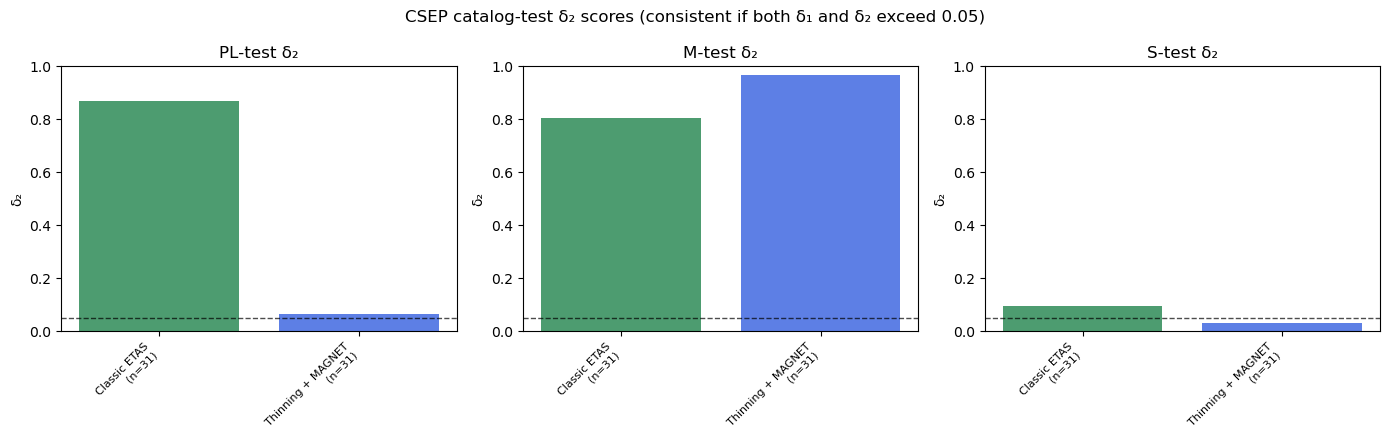

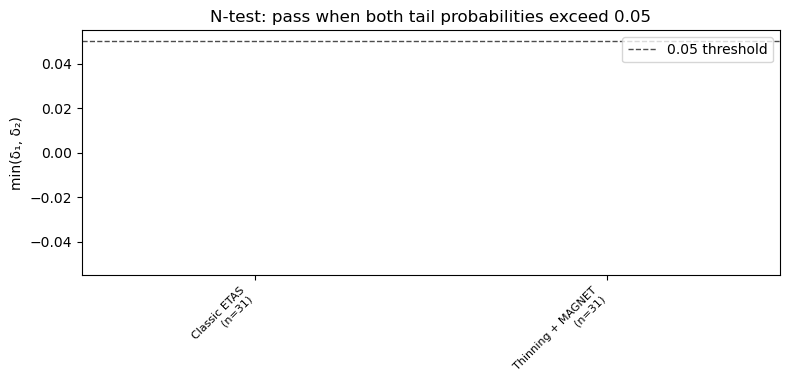

### PL-test diagnostic figures

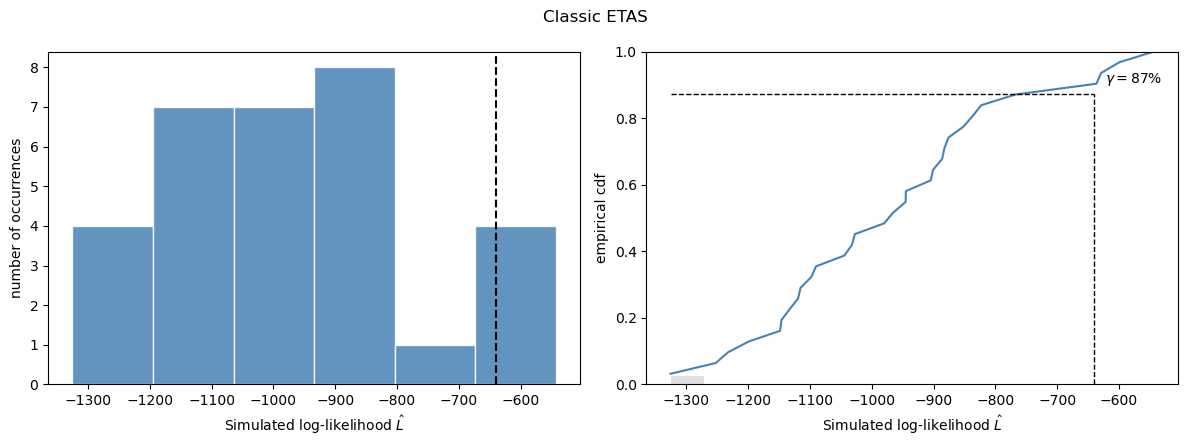

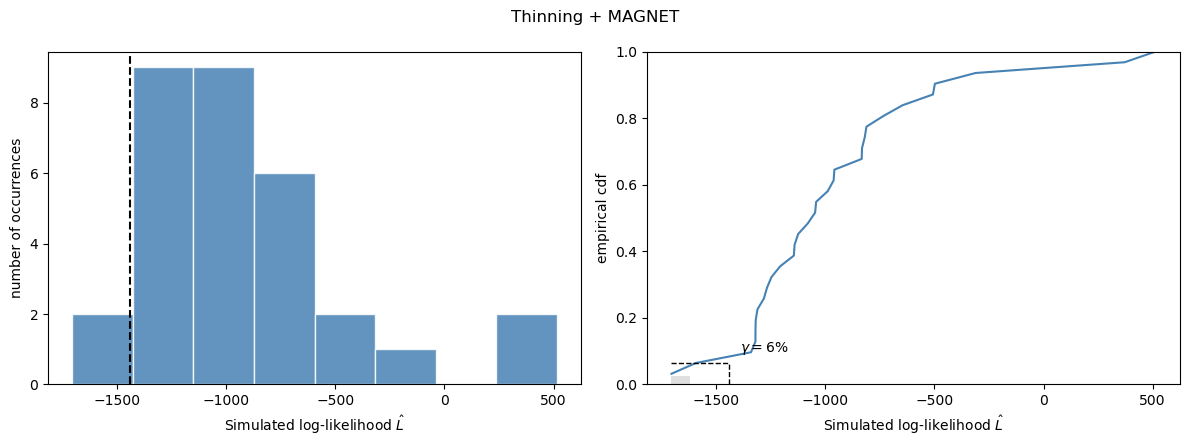

In [64]:
from csep.core import catalog_evaluations
from csep.core.catalogs import CSEPCatalog
from csep.core.forecasts import CatalogForecast
from csep.core.regions import california_relm_region, create_space_magnitude_region
from csep.utils.constants import CSEP_MW_BINS
from csep.utils.time_utils import datetime_to_utc_epoch
from etas.inversion import ETASParameterCalculation
from shapely.geometry import Polygon as ShapelyPolygon

CSEP_LTEST_ALPHA = 0.025


def plot_l_test(
    simulated_ll,
    observed_ll,
    gamma,
    alpha: float = 0.025,
    *,
    title: str | None = None,
):
    """Two-panel L-test figure: simulated-LL histogram and empirical CDF."""
    from matplotlib.patches import Rectangle

    simulated_ll = np.asarray(simulated_ll, dtype=float)
    observed_ll = float(observed_ll)
    gamma = float(gamma)
    alpha_level = float(alpha)

    fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

    ax_hist = axes[0]
    ax_hist.hist(simulated_ll, bins="auto", color="steelblue", edgecolor="white", alpha=0.85)
    ax_hist.axvline(observed_ll, color="black", ls="--", lw=1.5)
    ax_hist.set_xlabel(r"Simulated log-likelihood $\hat{L}$")
    ax_hist.set_ylabel("number of occurrences")

    ax_cdf = axes[1]
    x_sorted = np.sort(simulated_ll)
    ecdf = np.arange(1, x_sorted.size + 1, dtype=float) / x_sorted.size
    ax_cdf.plot(x_sorted, ecdf, color="steelblue", lw=1.5)

    x_min = float(simulated_ll.min())
    x_alpha = float(np.quantile(simulated_ll, alpha_level))
    ax_cdf.add_patch(
        Rectangle(
            (x_min, 0.0),
            x_alpha - x_min,
            alpha_level,
            facecolor="gray",
            alpha=0.25,
            linewidth=0,
            zorder=1,
        )
    )

    ax_cdf.plot([observed_ll, observed_ll], [0.0, gamma], color="black", ls="--", lw=1.0, zorder=3)
    ax_cdf.plot([x_min, observed_ll], [gamma, gamma], color="black", ls="--", lw=1.0, zorder=3)
    ax_cdf.annotate(
        rf"$\gamma = {100 * gamma:.0f}\%$",
        xy=(observed_ll, gamma),
        xytext=(8, 8),
        textcoords="offset points",
        fontsize=10,
    )
    ax_cdf.set_xlabel(r"Simulated log-likelihood $\hat{L}$")
    ax_cdf.set_ylabel("empirical cdf")
    ax_cdf.set_ylim(0.0, 1.0)

    if title:
        fig.suptitle(title, fontsize=12)
    fig.tight_layout()
    return fig


def _load_inversion_for_csep(output_root: Path, inv_id: str):
    params_json = output_root / "inversions" / f"inv_{inv_id}" / f"parameters_{inv_id}.json"
    if not params_json.is_file():
        raise FileNotFoundError(params_json)
    inversion_output = json.loads(params_json.read_text(encoding="utf-8"))
    etas_inversion = ETASParameterCalculation.load_calculation(inversion_output)
    return inversion_output, etas_inversion


def _csep_magnitude_bins(etas_inversion) -> np.ndarray:
    m_ref = float(etas_inversion.m_ref)
    delta_m = float(etas_inversion.delta_m)
    dmw = 0.1 if delta_m <= 0 else delta_m
    return np.arange(m_ref, float(CSEP_MW_BINS.max()) + dmw, dmw)


def _catalog_lat_lon_mag(df: pd.DataFrame) -> tuple[pd.Series, pd.Series, pd.Series]:
    lat = df["latitude"] if "latitude" in df.columns else df["y"]
    lon = df["longitude"] if "longitude" in df.columns else df["x"]
    mag_col = "m" if "m" in df.columns else "magnitude"
    mag = pd.to_numeric(df[mag_col], errors="coerce")
    return lat.astype(float), lon.astype(float), mag


def _filter_to_study_domain(df: pd.DataFrame, *, m_ref: float, study_poly: ShapelyPolygon) -> pd.DataFrame:
    lat, lon, mag = _catalog_lat_lon_mag(df)
    mask = mag >= m_ref
    if not mask.any():
        return df.iloc[0:0].copy()
    lat = lat[mask]
    lon = lon[mask]
    out = df.loc[mask].copy()
    geom = gpd.points_from_xy(lat, lon)
    in_poly = gpd.GeoSeries(geom).intersects(study_poly).to_numpy()
    return out.loc[in_poly].copy()


def _filter_to_csep_region(df: pd.DataFrame, *, region, m_ref: float, study_poly: ShapelyPolygon) -> pd.DataFrame:
    out = _filter_to_study_domain(df, m_ref=m_ref, study_poly=study_poly)
    if out.empty:
        return out
    lat, lon, _ = _catalog_lat_lon_mag(out)
    in_region = ~region.get_masked(lon.to_numpy(), lat.to_numpy())
    return out.loc[in_region].copy()


def _catalog_origin_time_epoch(df: pd.DataFrame) -> pd.Series:
    if "time" in df.columns:
        return pd.to_datetime(df["time"], utc=True).map(datetime_to_utc_epoch)
    if "t" in df.columns:
        epochs = pd.Timestamp("1970-01-01", tz="UTC") + pd.to_timedelta(df["t"], unit="D")
        return epochs.map(datetime_to_utc_epoch)
    raise KeyError("catalog needs a 'time' or 't' column for CSEP conversion")


def dataframe_to_csep_catalog(df: pd.DataFrame, *, catalog_id: int, region) -> CSEPCatalog:
    lat, lon, mag = _catalog_lat_lon_mag(df)
    csep_df = pd.DataFrame(
        {
            "id": [f"evt_{i}" for i in range(len(df))],
            "origin_time": _catalog_origin_time_epoch(df),
            "latitude": lat,
            "longitude": lon,
            "depth": np.zeros(len(df)),
            "magnitude": mag,
            "catalog_id": catalog_id,
        }
    )
    return CSEPCatalog.from_dataframe(csep_df, region=region)


def build_catalog_forecast_from_dataframes(
    catalogs: list[pd.DataFrame],
    *,
    name: str,
    region,
    start_time,
    end_time,
    m_ref: float,
    study_poly: ShapelyPolygon,
) -> CatalogForecast | None:
    simulated_catalogs: list[CSEPCatalog] = []
    for i, raw_df in enumerate(catalogs):
        filtered = _filter_to_csep_region(raw_df, region=region, m_ref=m_ref, study_poly=study_poly)
        if filtered.empty:
            continue
        simulated_catalogs.append(dataframe_to_csep_catalog(filtered, catalog_id=i, region=region))
    if not simulated_catalogs:
        return None
    return CatalogForecast(
        catalogs=simulated_catalogs,
        region=region,
        name=name,
        start_time=start_time,
        end_time=end_time,
        n_cat=len(simulated_catalogs),
        filter_spatial=True,
        apply_filters=True,
    )


def run_csep_catalog_tests(forecast: CatalogForecast, observed_catalog: CSEPCatalog) -> dict:
    l_result = catalog_evaluations.pseudolikelihood_test(forecast, observed_catalog)
    if l_result is None:
        raise ValueError("pseudolikelihood_test returned None (empty or invalid observed catalog)")
    n_result = catalog_evaluations.number_test(forecast, observed_catalog)
    m_result = catalog_evaluations.magnitude_test(forecast, observed_catalog)
    s_result = catalog_evaluations.spatial_test(forecast, observed_catalog)

    n_delta1, n_delta2 = n_result.quantile
    l_delta1, l_delta2 = l_result.quantile
    m_delta1, m_delta2 = m_result.quantile
    s_delta1, s_delta2 = s_result.quantile
    simulated_ll = np.asarray(l_result.test_distribution, dtype=float)
    observed_ll = float(l_result.observed_statistic)

    return {
        "L_delta1": float(l_delta1),
        "L_delta2": float(l_delta2),
        "L_quantile": float(l_delta2),
        "N_delta1": float(n_delta1),
        "N_delta2": float(n_delta2),
        "N_pass": bool(n_delta1 > 0.05 and n_delta2 > 0.05),
        "M_delta1": float(m_delta1),
        "M_delta2": float(m_delta2),
        "M_quantile": float(m_delta2),
        "S_delta1": float(s_delta1),
        "S_delta2": float(s_delta2),
        "S_quantile": float(s_delta2),
        "n_forecast": float(np.mean(forecast.get_event_counts())),
        "n_observed": float(observed_catalog.event_count),
        "L_obs_ll": observed_ll,
        "simulated_ll": simulated_ll,
    }


_, etas_inversion = _load_inversion_for_csep(OUTPUT_ROOT, inv_id)
m_ref = float(etas_inversion.m_ref)
study_poly = ShapelyPolygon(etas_inversion.shape_coords)
mag_bins = _csep_magnitude_bins(etas_inversion)
csep_region = create_space_magnitude_region(california_relm_region(), mag_bins)

forecast_start = pd.to_datetime(primary_meta["timewindow_end"], utc=True).to_pydatetime()
forecast_end = pd.to_datetime(primary_meta["testwindow_end"], utc=True).to_pydatetime()

original_catalog_path = Path(etas_inversion.fn_catalog)
if not original_catalog_path.is_file():
    original_catalog_path = REPO_ROOT / "input_data" / original_catalog_path.name
observed_raw = pd.read_csv(original_catalog_path)
observed_raw["time"] = pd.to_datetime(observed_raw["time"], utc=True).dt.tz_convert(None)
forecast_start_dt = pd.to_datetime(primary_meta["timewindow_end"], utc=True).tz_convert(None)
forecast_end_dt = pd.to_datetime(primary_meta["testwindow_end"], utc=True).tz_convert(None)
observed_raw = observed_raw.loc[
    (observed_raw["time"] > forecast_start_dt)
    & (observed_raw["time"] <= forecast_end_dt)
].copy()
observed_filtered = _filter_to_csep_region(
    observed_raw,
    region=csep_region,
    m_ref=m_ref,
    study_poly=study_poly,
)
observed_catalog = dataframe_to_csep_catalog(observed_filtered, catalog_id=0, region=csep_region)
observed_catalog.name = "observed_test_catalog"

display(
    Markdown(
        f"CSEP region: `{csep_region.name}` — {csep_region.num_nodes} spatial cells, "
        f"{len(csep_region.magnitudes)} magnitude bins from **m ≥ {m_ref:.2f}**; "
        f"observed test events in region: **{observed_catalog.event_count}**"
    )
)

csep_rows: list[dict] = []
l_test_results: dict[str, dict] = {}
for method, catalogs in catalogs_by_method.items():
    simulated_catalog_dfs = [catalogs[seed] for seed in selected_seeds]
    catalog_forecast = build_catalog_forecast_from_dataframes(
        simulated_catalog_dfs,
        name=METHOD_LABELS.get(method, method),
        region=csep_region,
        start_time=forecast_start,
        end_time=forecast_end,
        m_ref=m_ref,
        study_poly=study_poly,
    )
    if catalog_forecast is None:
        continue

    scores = run_csep_catalog_tests(catalog_forecast, observed_catalog)
    realization = METHOD_LABELS.get(method, method)
    simulated_ll = scores.pop("simulated_ll")
    l_test_results[realization] = {
        "simulated_ll": simulated_ll,
        "observed_ll": scores["L_obs_ll"],
        "gamma": scores["L_quantile"],
    }
    csep_rows.append(
        {
            "method": method,
            "label": realization,
            "seed": "ensemble",
            "n_realizations": int(catalog_forecast.n_cat),
            "realization": realization,
            **scores,
        }
    )

if not csep_rows:
    display(Markdown("_No CSEP scores computed (empty catalogs after filtering)._"))
else:
    csep_scores = pd.DataFrame(csep_rows)

    summary_cols = [
        "method",
        "realization",
        "label",
        "n_realizations",
        "n_forecast",
        "n_observed",
        "L_delta1",
        "L_delta2",
        "N_delta1",
        "N_delta2",
        "N_pass",
        "M_delta1",
        "M_delta2",
        "S_delta1",
        "S_delta2",
    ]
    display(Markdown("### Scores by method (catalog ensemble)"))
    csep_scores_sorted = csep_scores.sort_values(["method"]).reset_index(drop=True)
    display(csep_scores_sorted[summary_cols])

    plot_df = csep_scores_sorted.copy()
    x = np.arange(len(plot_df))

    fig, axes = plt.subplots(1, 3, figsize=(14, 4.5), sharex=True)
    for ax, col, title in [
        (axes[0], "L_delta2", "PL-test δ₂"),
        (axes[1], "M_delta2", "M-test δ₂"),
        (axes[2], "S_delta2", "S-test δ₂"),
    ]:
        colors = [METHOD_COLORS.get(m, "gray") for m in plot_df["method"]]
        ax.bar(x, plot_df[col], color=colors, alpha=0.85)
        ax.axhline(0.05, color="black", ls="--", lw=1.0, alpha=0.7)
        ax.set_ylabel("δ₂")
        ax.set_title(title)
        ax.set_ylim(0.0, 1.0)
    tick_labels = [
        f"{lbl}\n(n={n_real})"
        for lbl, n_real in zip(plot_df["label"], plot_df["n_realizations"])
    ]
    for ax in axes:
        ax.set_xticks(x)
        ax.set_xticklabels(tick_labels, rotation=45, ha="right", fontsize=8)
    fig.suptitle("CSEP catalog-test δ₂ scores (consistent if both δ₁ and δ₂ exceed 0.05)", fontsize=12)
    fig.tight_layout()
    show_fig(fig)

    fig, ax = plt.subplots(figsize=(max(8, 1.2 * len(plot_df)), 4.0))
    n_colors = ["seagreen" if p else "indianred" for p in plot_df["N_pass"]]
    ax.bar(x, np.minimum(plot_df["N_delta1"], plot_df["N_delta2"]), color=n_colors, alpha=0.85)
    ax.axhline(0.05, color="black", ls="--", lw=1.0, alpha=0.7, label="0.05 threshold")
    ax.set_xticks(x)
    ax.set_xticklabels(tick_labels, rotation=45, ha="right", fontsize=8)
    ax.set_ylabel("min(δ₁, δ₂)")
    ax.set_title("N-test: pass when both tail probabilities exceed 0.05")
    ax.legend(loc="upper right")
    fig.tight_layout()
    show_fig(fig)

    display(Markdown("### PL-test diagnostic figures"))
    for realization in sorted(l_test_results):
        l_data = l_test_results[realization]
        fig = plot_l_test(
            l_data["simulated_ll"],
            l_data["observed_ll"],
            l_data["gamma"],
            alpha=CSEP_LTEST_ALPHA,
            title=realization,
        )
        show_fig(fig)
